# Phishing Website Detection Using Machine Learning

---

# Abstract

Phishing websites are among the most dangerous cybersecurity threats that deceive users into revealing confidential information.

This research develops a machine learning-based phishing website detection system using:
- Exploratory Data Analysis
- Feature Engineering
- Cross Validation
- Ensemble Learning
- Comparative Model Analysis

Ten machine learning algorithms are evaluated using:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

The project also includes:
- Hard Voting Classifier
- Soft Voting Classifier
- 50+ Professional Visualizations
- Cross Validation
- Learning Curve Analysis
- Feature Importance Analysis


# Import Libraries

This section imports all required libraries for:
- Data analysis
- Data visualization
- Machine learning
- Model evaluation
- Ensemble learning
- Cross validation

In [54]:
# ==========================================
# Standard Libraries
# ==========================================

import warnings
warnings.filterwarnings('ignore')

# ==========================================
# Data Manipulation
# ==========================================

import numpy as np
import pandas as pd

# ==========================================
# Visualization
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Machine Learning Utilities
# ==========================================

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    learning_curve,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

# ==========================================
# Machine Learning Models
# ==========================================

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.naive_bayes import GaussianNB

from sklearn.svm import SVC

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    VotingClassifier
)

from xgboost import XGBClassifier

# ==========================================
# Evaluation Metrics
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Dataset Loading

The phishing dataset is loaded using Pandas DataFrame.

In [55]:
df = pd.read_csv("phishing.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (11054, 32)


,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
0,0,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
1,1,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
2,2,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
3,3,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1
4,4,-1,0,-1,1,-1,-1,1,1,-1,...,1,1,1,1,1,-1,1,-1,-1,1


# Dataset Overview

This section provides:
- Data types
- Number of rows and columns
- Overall dataset structure

In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11054 entries, 0 to 11053
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Index                11054 non-null  int64
 1   UsingIP              11054 non-null  int64
 2   LongURL              11054 non-null  int64
 3   ShortURL             11054 non-null  int64
 4   Symbol@              11054 non-null  int64
 5   Redirecting//        11054 non-null  int64
 6   PrefixSuffix-        11054 non-null  int64
 7   SubDomains           11054 non-null  int64
 8   HTTPS                11054 non-null  int64
 9   DomainRegLen         11054 non-null  int64
 10  Favicon              11054 non-null  int64
 11  NonStdPort           11054 non-null  int64
 12  HTTPSDomainURL       11054 non-null  int64
 13  RequestURL           11054 non-null  int64
 14  AnchorURL            11054 non-null  int64
 15  LinksInScriptTags    11054 non-null  int64
 16  ServerFormHandler    11054 non-nu

# Statistical Summary

Descriptive statistics help understand:
- Mean
- Standard deviation
- Quartiles
- Minimum & maximum values

In [57]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Index,11054.0,5526.500000,3191.159272,0.0,2763.25,5526.5,8289.75,11053.0
UsingIP,11054.0,0.313914,0.949495,-1.0,-1.00,1.0,1.00,1.0
LongURL,11054.0,-0.633345,0.765973,-1.0,-1.00,-1.0,-1.00,1.0
ShortURL,11054.0,0.738737,0.674024,-1.0,1.00,1.0,1.00,1.0
Symbol@,11054.0,0.700561,0.713625,-1.0,1.00,1.0,1.00,1.0
Redirecting//,11054.0,0.741632,0.670837,-1.0,1.00,1.0,1.00,1.0
PrefixSuffix-,11054.0,-0.734938,0.678165,-1.0,-1.00,-1.0,-1.00,1.0
SubDomains,11054.0,0.064049,0.817492,-1.0,-1.00,0.0,1.00,1.0
HTTPS,11054.0,0.251040,0.911856,-1.0,-1.00,1.0,1.00,1.0
DomainRegLen,11054.0,-0.336711,0.941651,-1.0,-1.00,-1.0,1.00,1.0


# Missing Value Analysis

Checking missing values ensures data quality.

In [58]:
df.isnull().sum()

Index                  0
UsingIP                0
LongURL                0
ShortURL               0
Symbol@                0
Redirecting//          0
PrefixSuffix-          0
SubDomains             0
HTTPS                  0
DomainRegLen           0
Favicon                0
NonStdPort             0
HTTPSDomainURL         0
RequestURL             0
AnchorURL              0
LinksInScriptTags      0
ServerFormHandler      0
InfoEmail              0
AbnormalURL            0
WebsiteForwarding      0
StatusBarCust          0
DisableRightClick      0
UsingPopupWindow       0
IframeRedirection      0
AgeofDomain            0
DNSRecording           0
WebsiteTraffic         0
PageRank               0
GoogleIndex            0
LinksPointingToPage    0
StatsReport            0
class                  0
dtype: int64

# MISSING VALUE HEATMAP

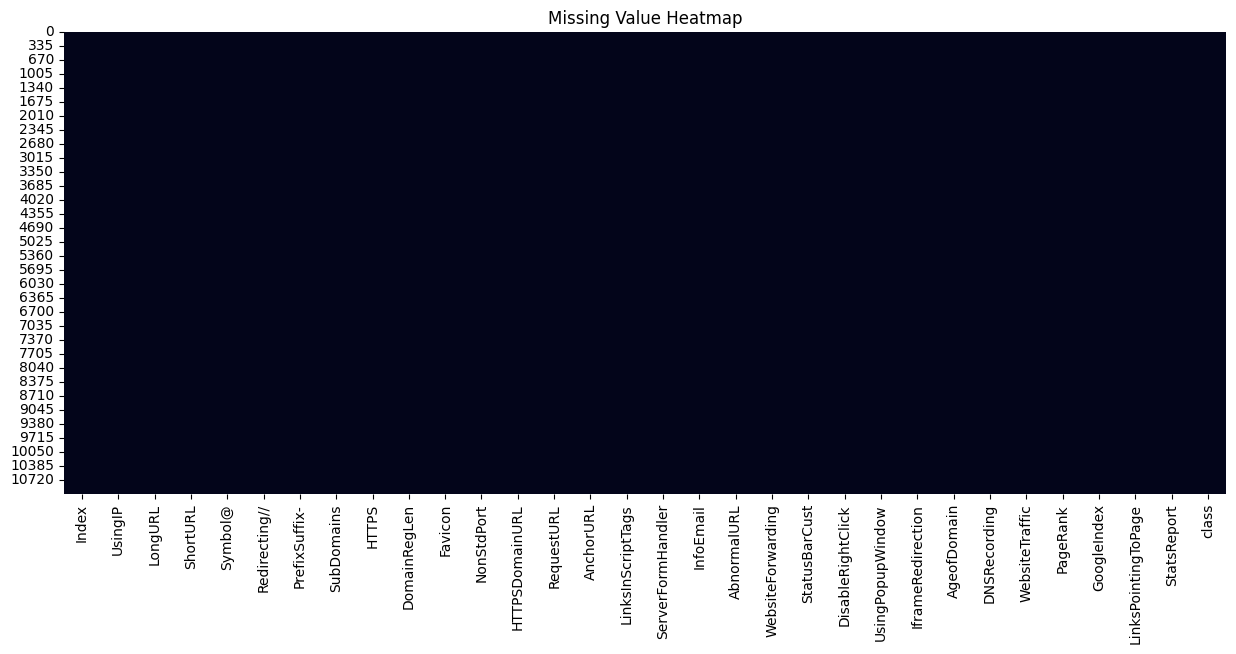

In [59]:
plt.figure(figsize=(15,6))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Value Heatmap")

plt.show()

# Target Distribution

Visualizing phishing vs legitimate class distribution.

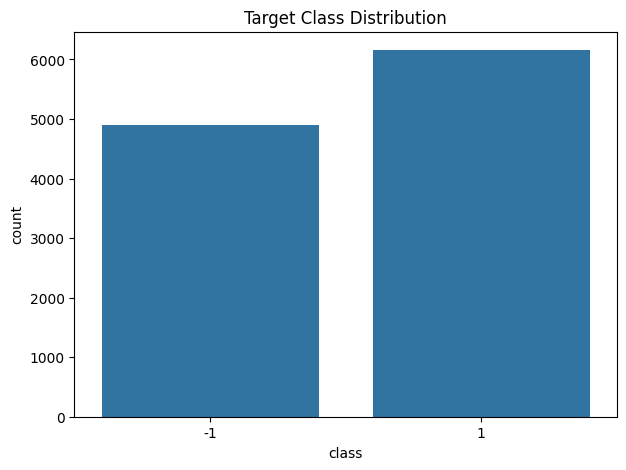

In [60]:
plt.figure(figsize=(7,5))

sns.countplot(x='class', data=df)

plt.title("Target Class Distribution")

plt.show()

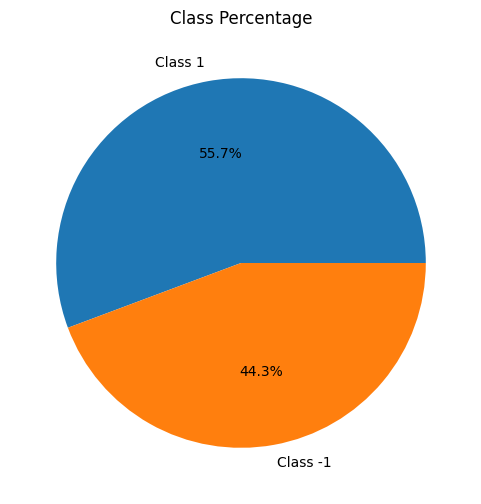

In [61]:
df['class'].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(6,6),
    labels=[f'Class {cls}' for cls in df['class'].value_counts().index]
)

plt.title("Class Percentage")
plt.ylabel("")
plt.show()

# Histogram Analysis

Histograms show feature distributions.

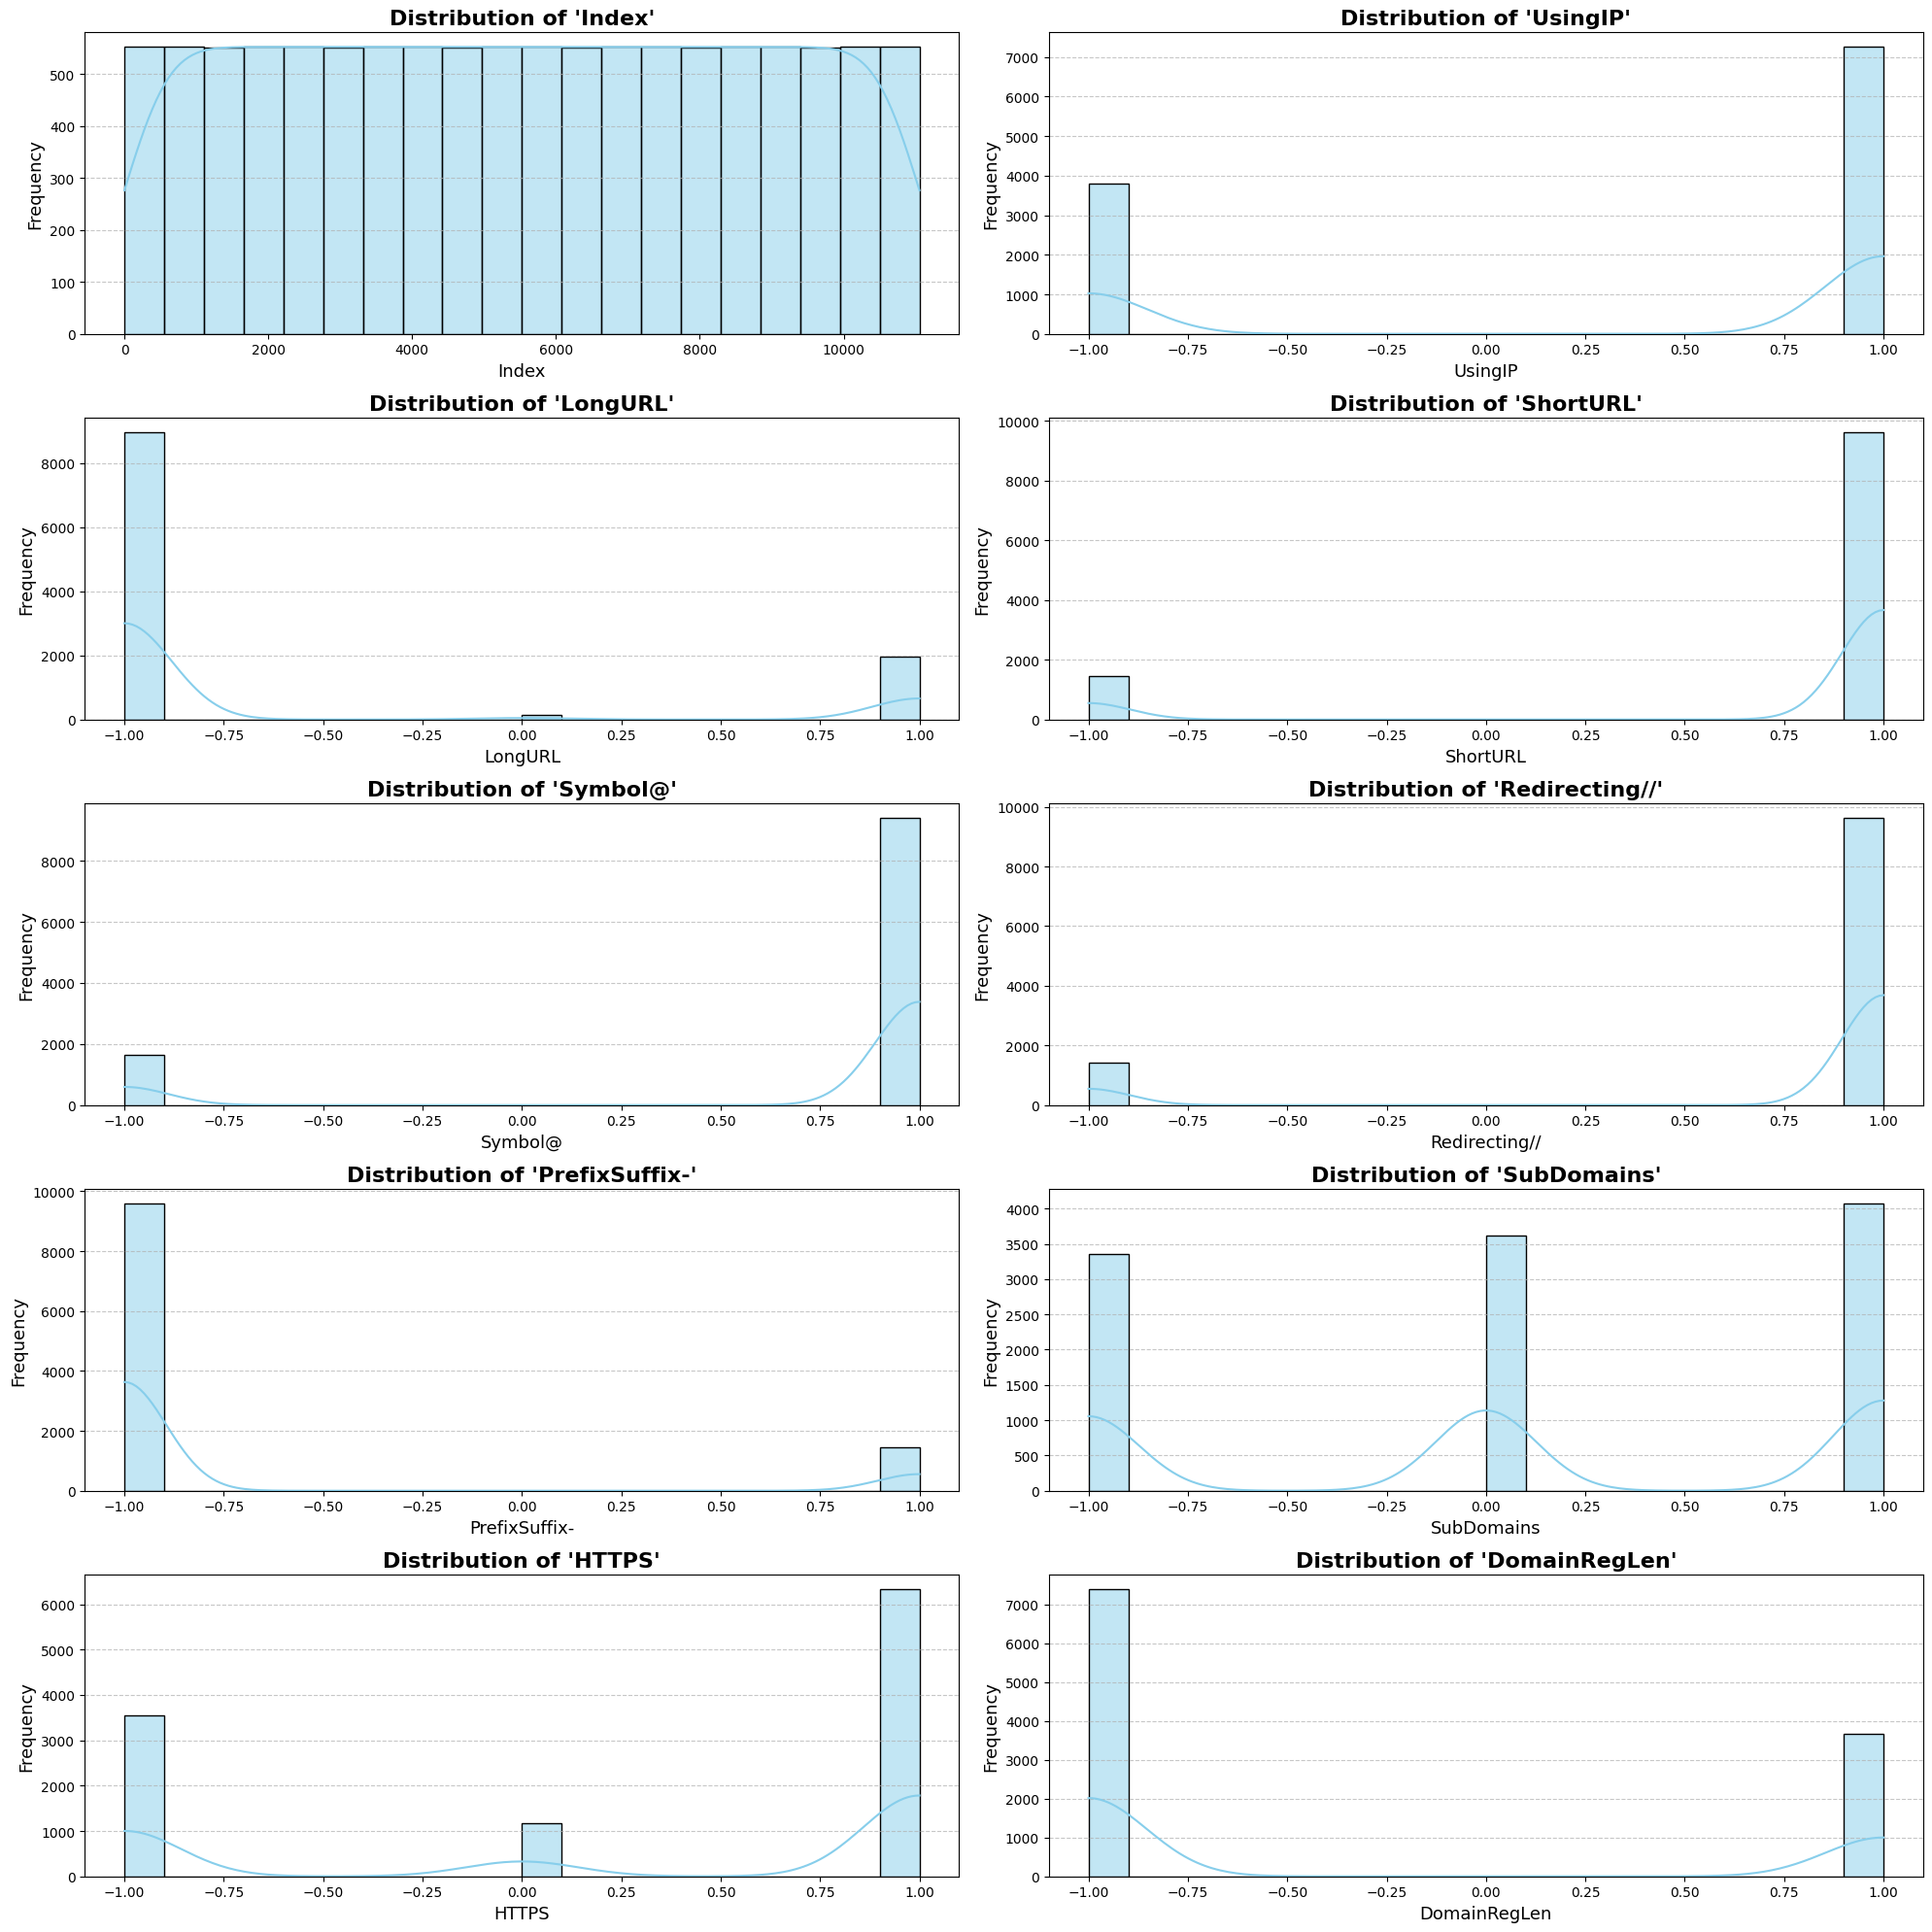

In [62]:
import seaborn as sns

fig, axes = plt.subplots(5, 2, figsize=(20, 20))  # 10 features = 5 rows x 2 columns
axes = axes.flatten()

for i, col in enumerate(df.columns[:10]):
    sns.histplot(df[col], bins=20, kde=True, color="skyblue", edgecolor='black', ax=axes[i])
    axes[i].set_title(f"Distribution of '{col}'", fontsize=16, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=13)
    axes[i].set_ylabel("Frequency", fontsize=13)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# Hide unused axes if any
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# ## Histogram Analysis of First 10 Features

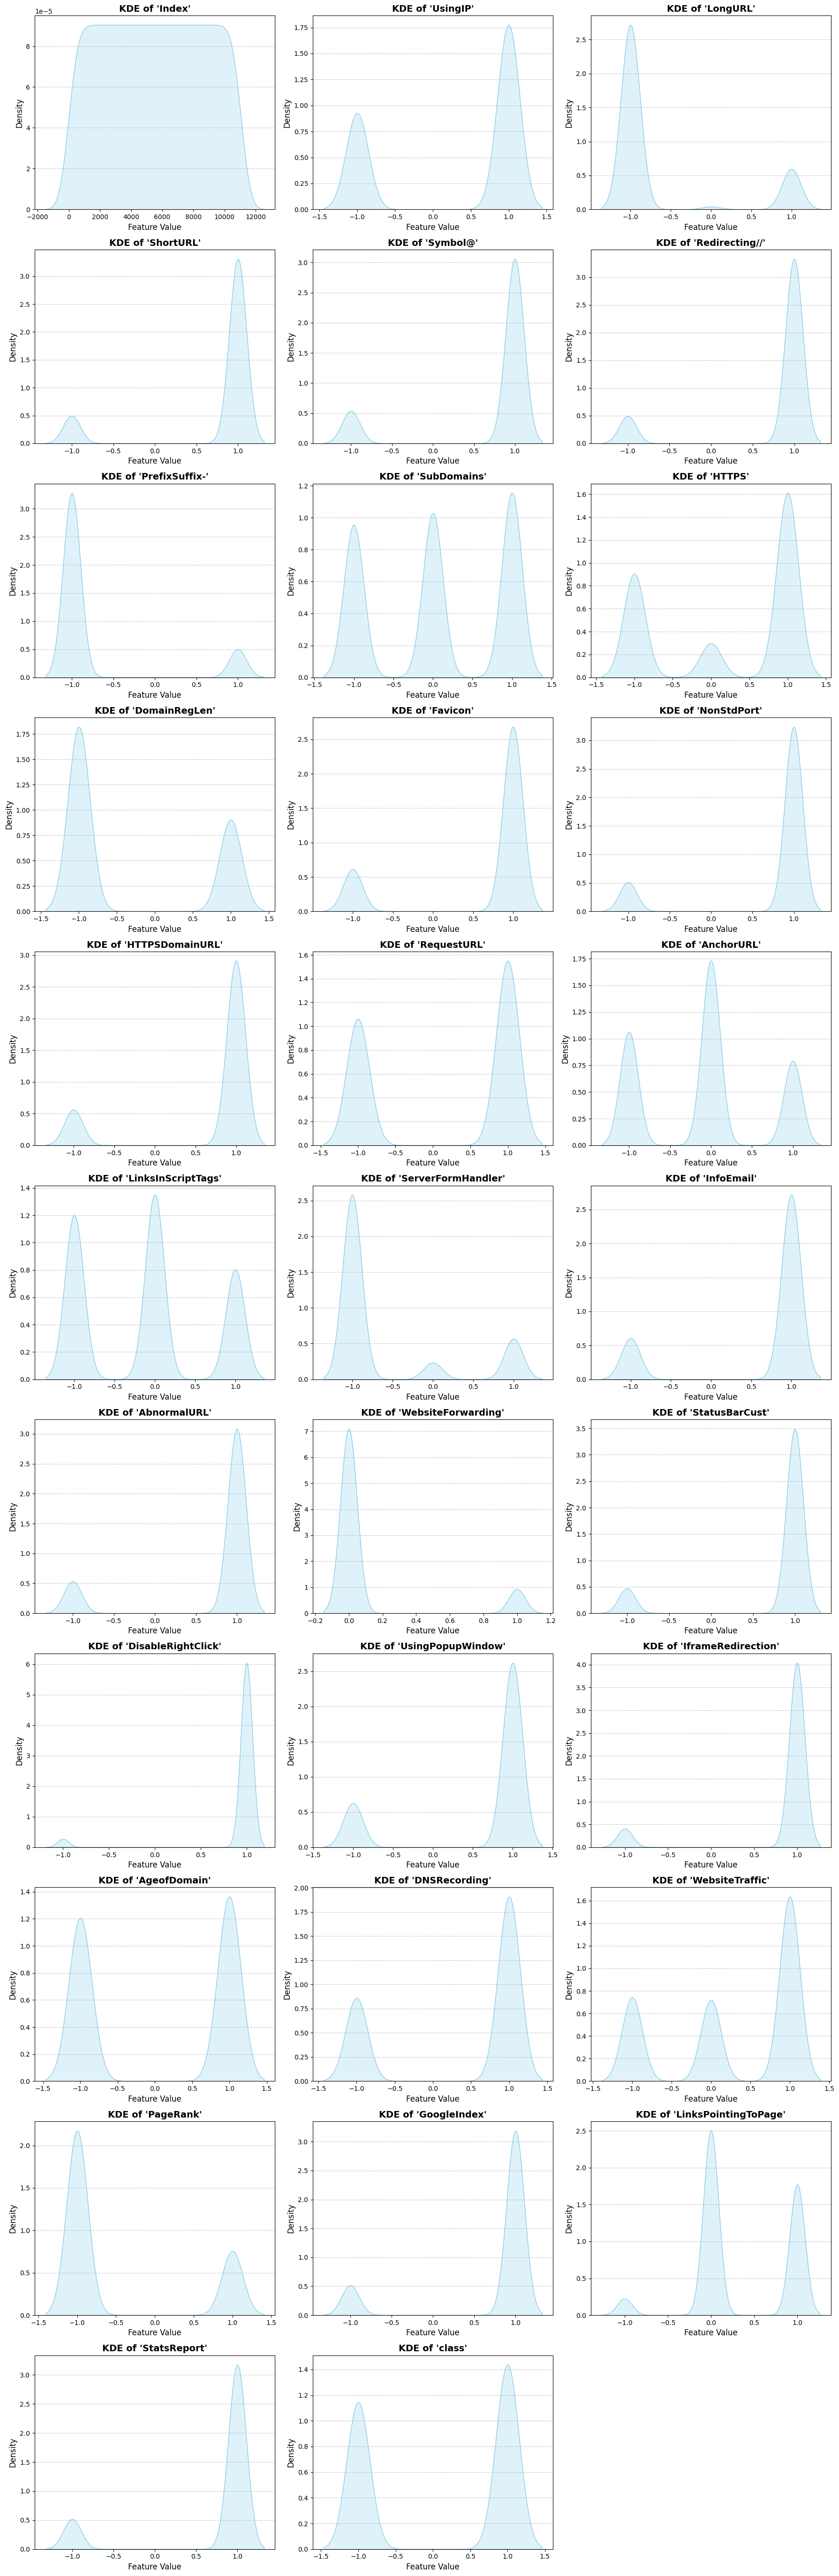

In [63]:
# KDE Plots for each numerical feature (one per subplot, in a grid)

import seaborn as sns

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.kdeplot(df[col], ax=axes[i], shade=True, color='skyblue')
    axes[i].set_title(f"KDE of '{col}'", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Feature Value", fontsize=12)
    axes[i].set_ylabel("Density", fontsize=12)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

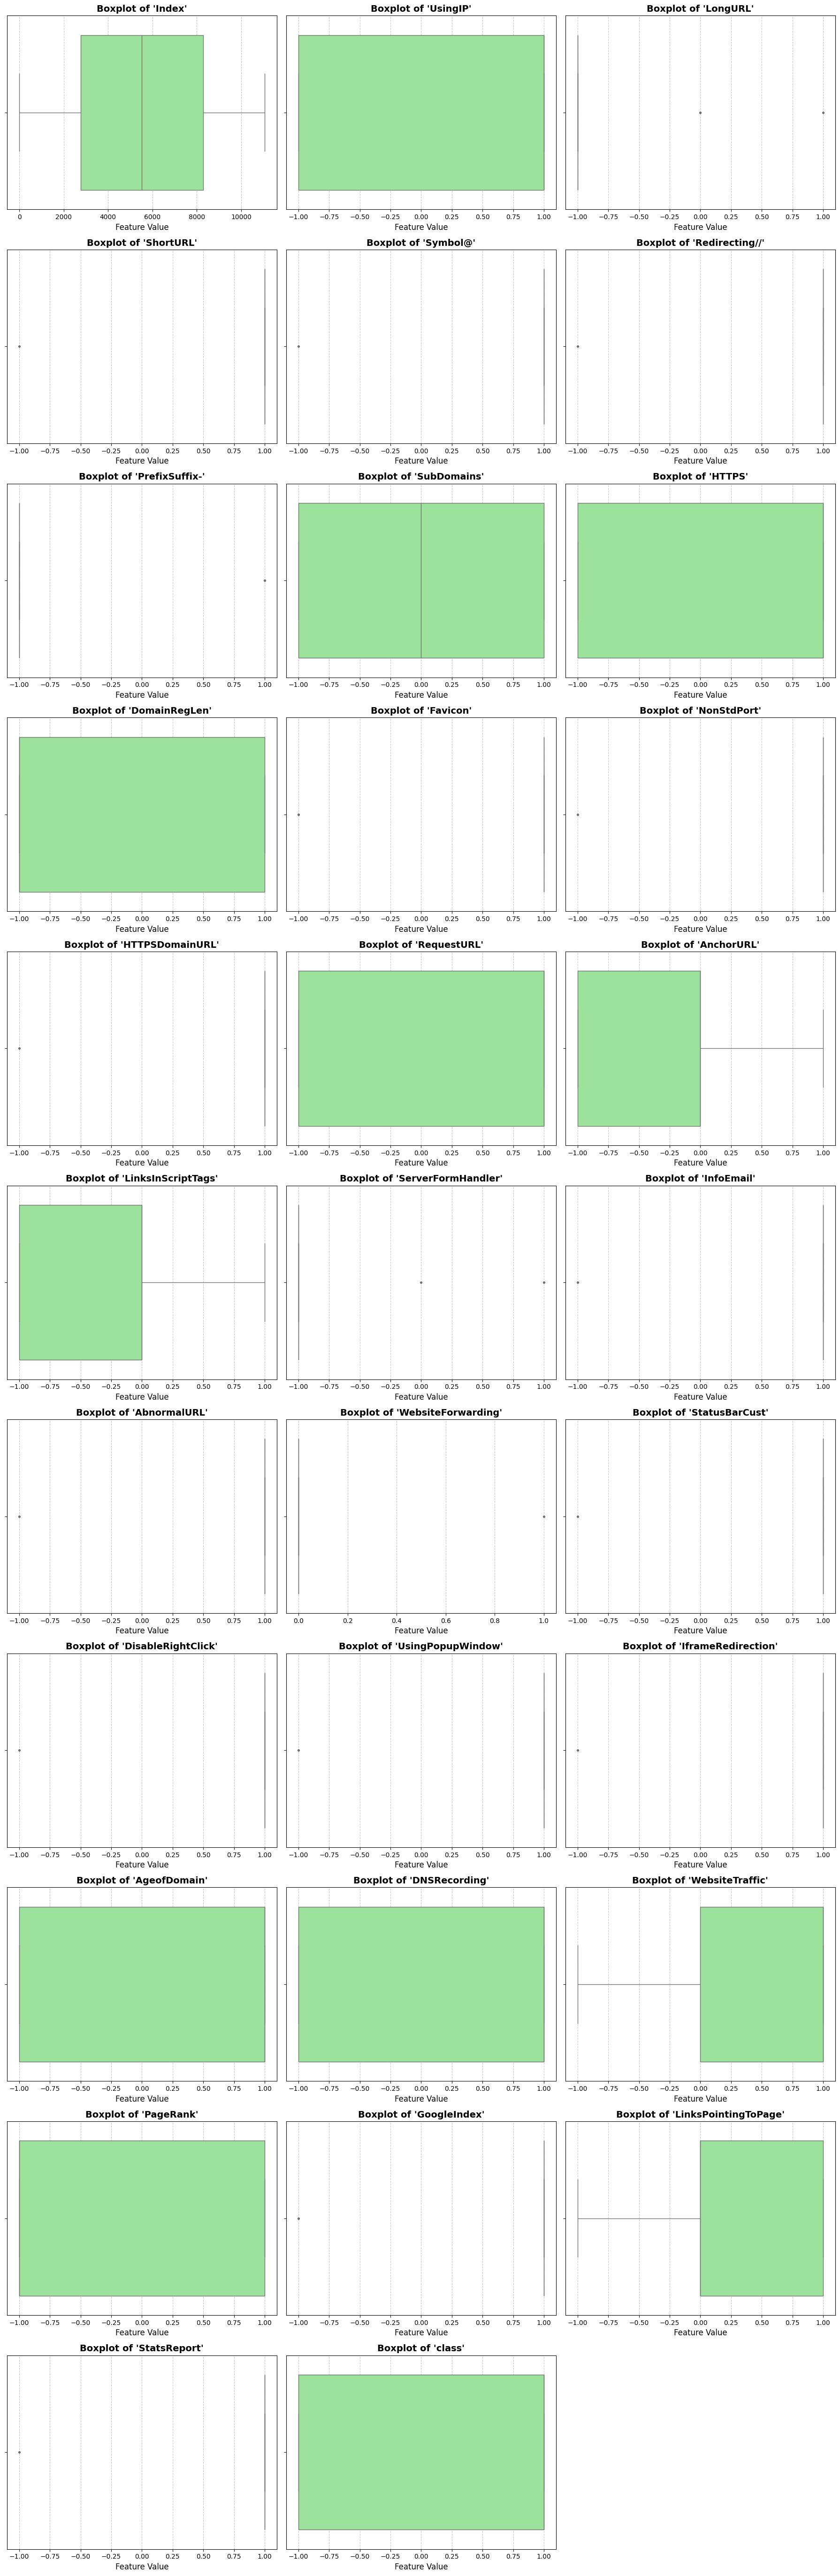

In [64]:
# Boxplots for each numerical feature (one per subplot, in a grid)

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='lightgreen', fliersize=2)
    axes[i].set_title(f"Boxplot of '{col}'", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Feature Value", fontsize=12)
    axes[i].grid(axis='x', linestyle='--', alpha=0.7)

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## VIOLIN PLOTS

# Violin plots for each numerical feature (one per subplot, in a grid)



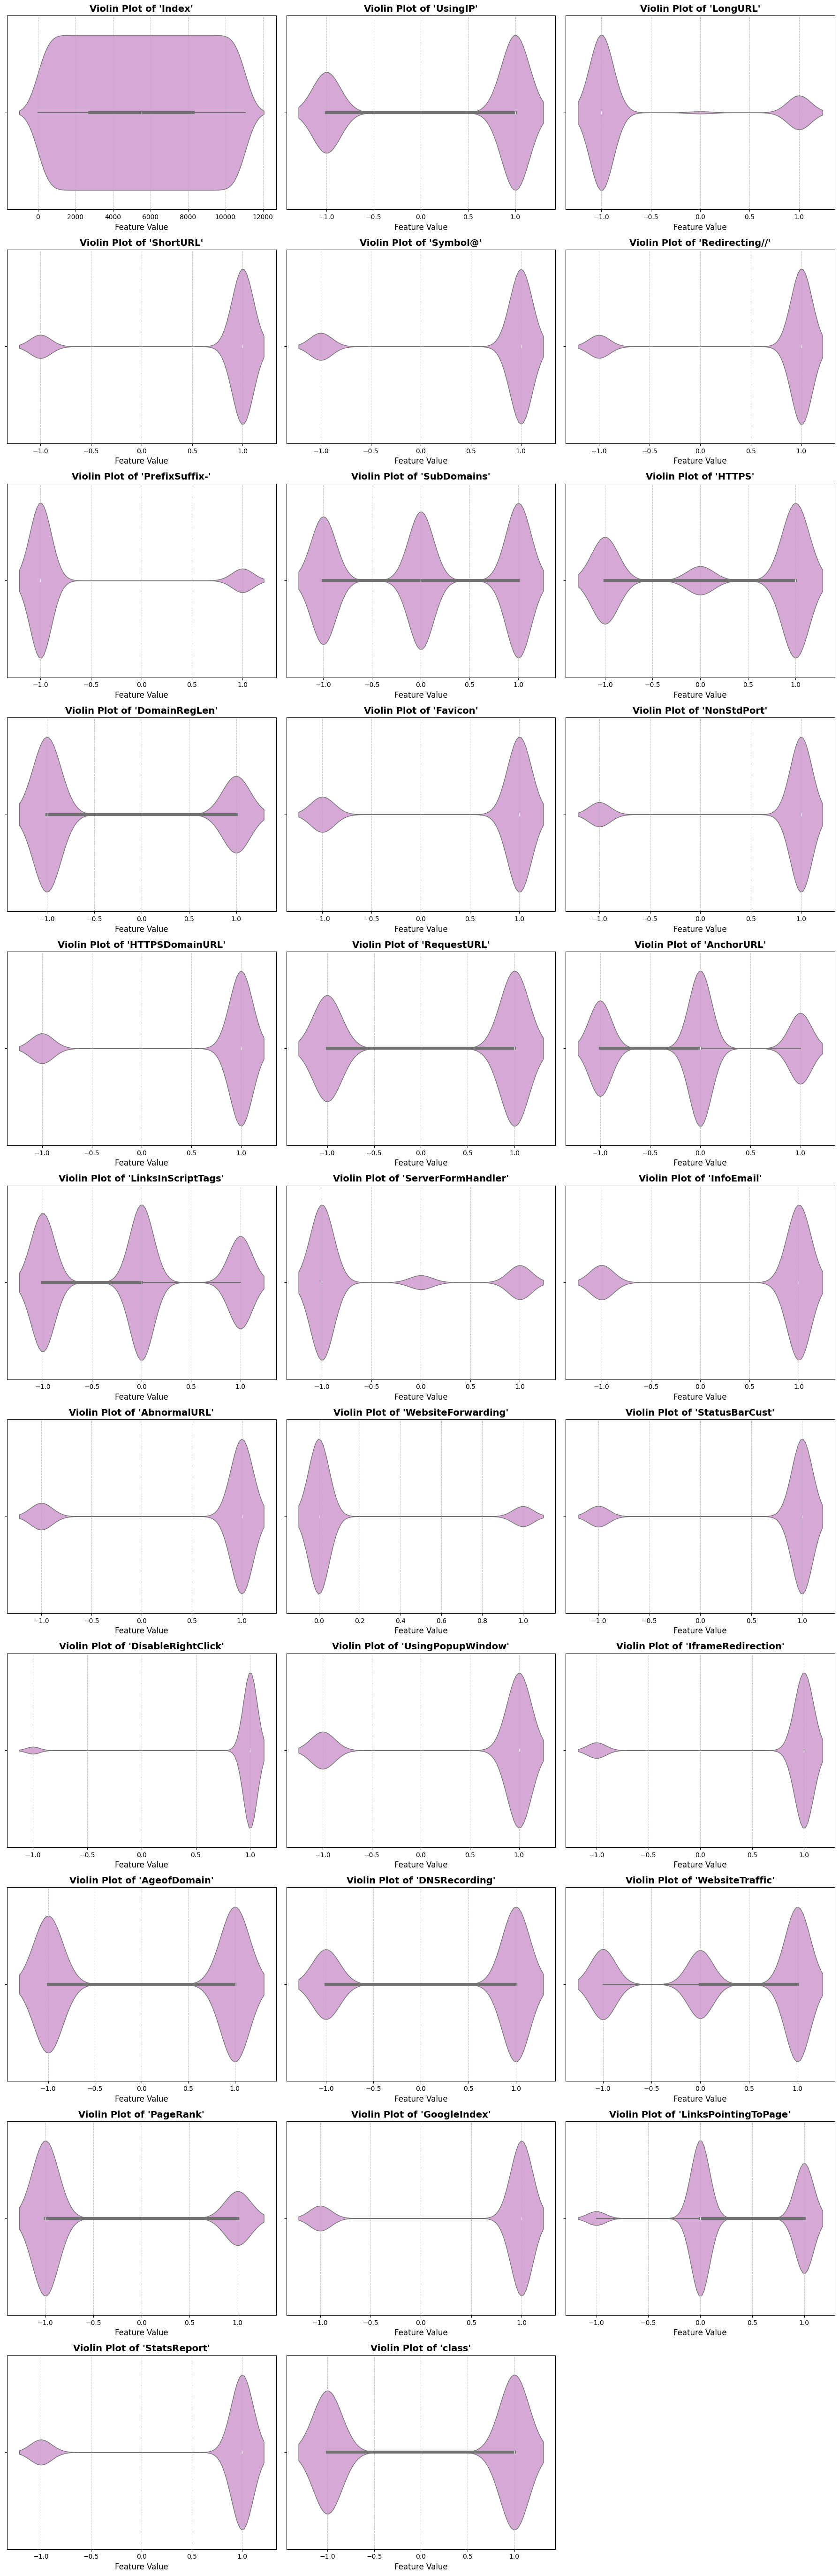

In [65]:
# Violin plots for each numerical feature (one per subplot, in a grid)

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.violinplot(x=df[col], ax=axes[i], color='plum', linewidth=1)
    axes[i].set_title(f"Violin Plot of '{col}'", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Feature Value", fontsize=12)
    axes[i].grid(axis='x', linestyle='--', alpha=0.7)

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Correlation Analysis

Shows relationships among features.

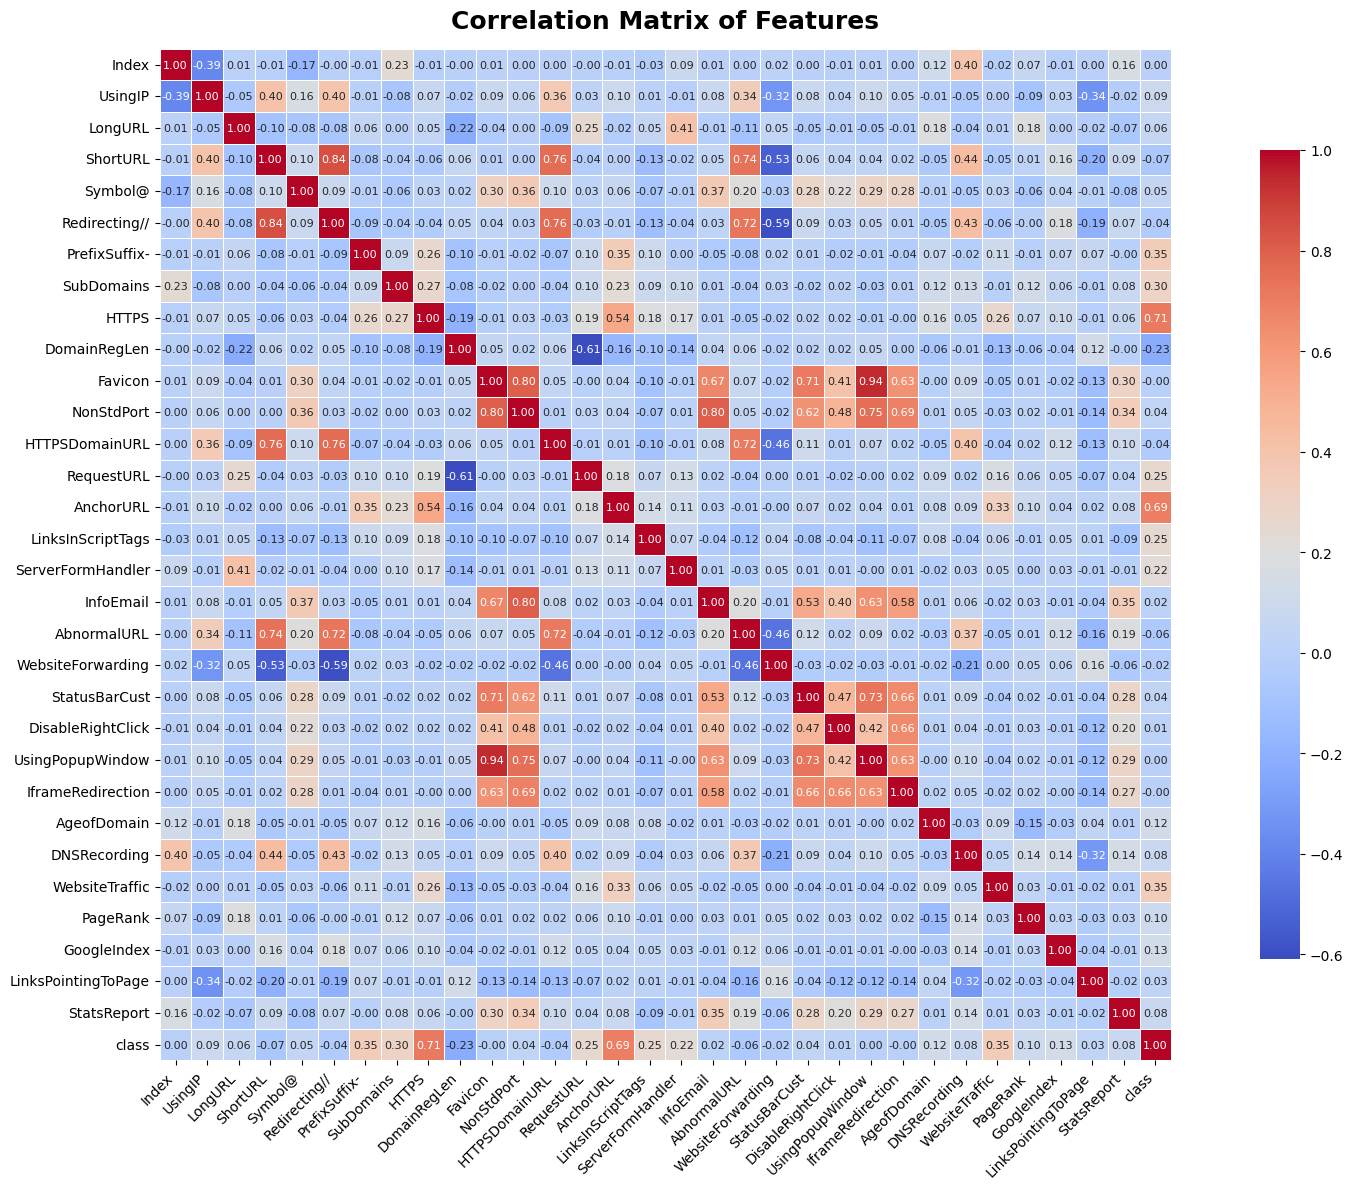

In [66]:
# Compute correlation matrix
corr_matrix = df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(18, 12))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=.5,
    square=True,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 8}
)

plt.title("Correlation Matrix of Features", fontsize=18, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# Pairplot for selected important features + class

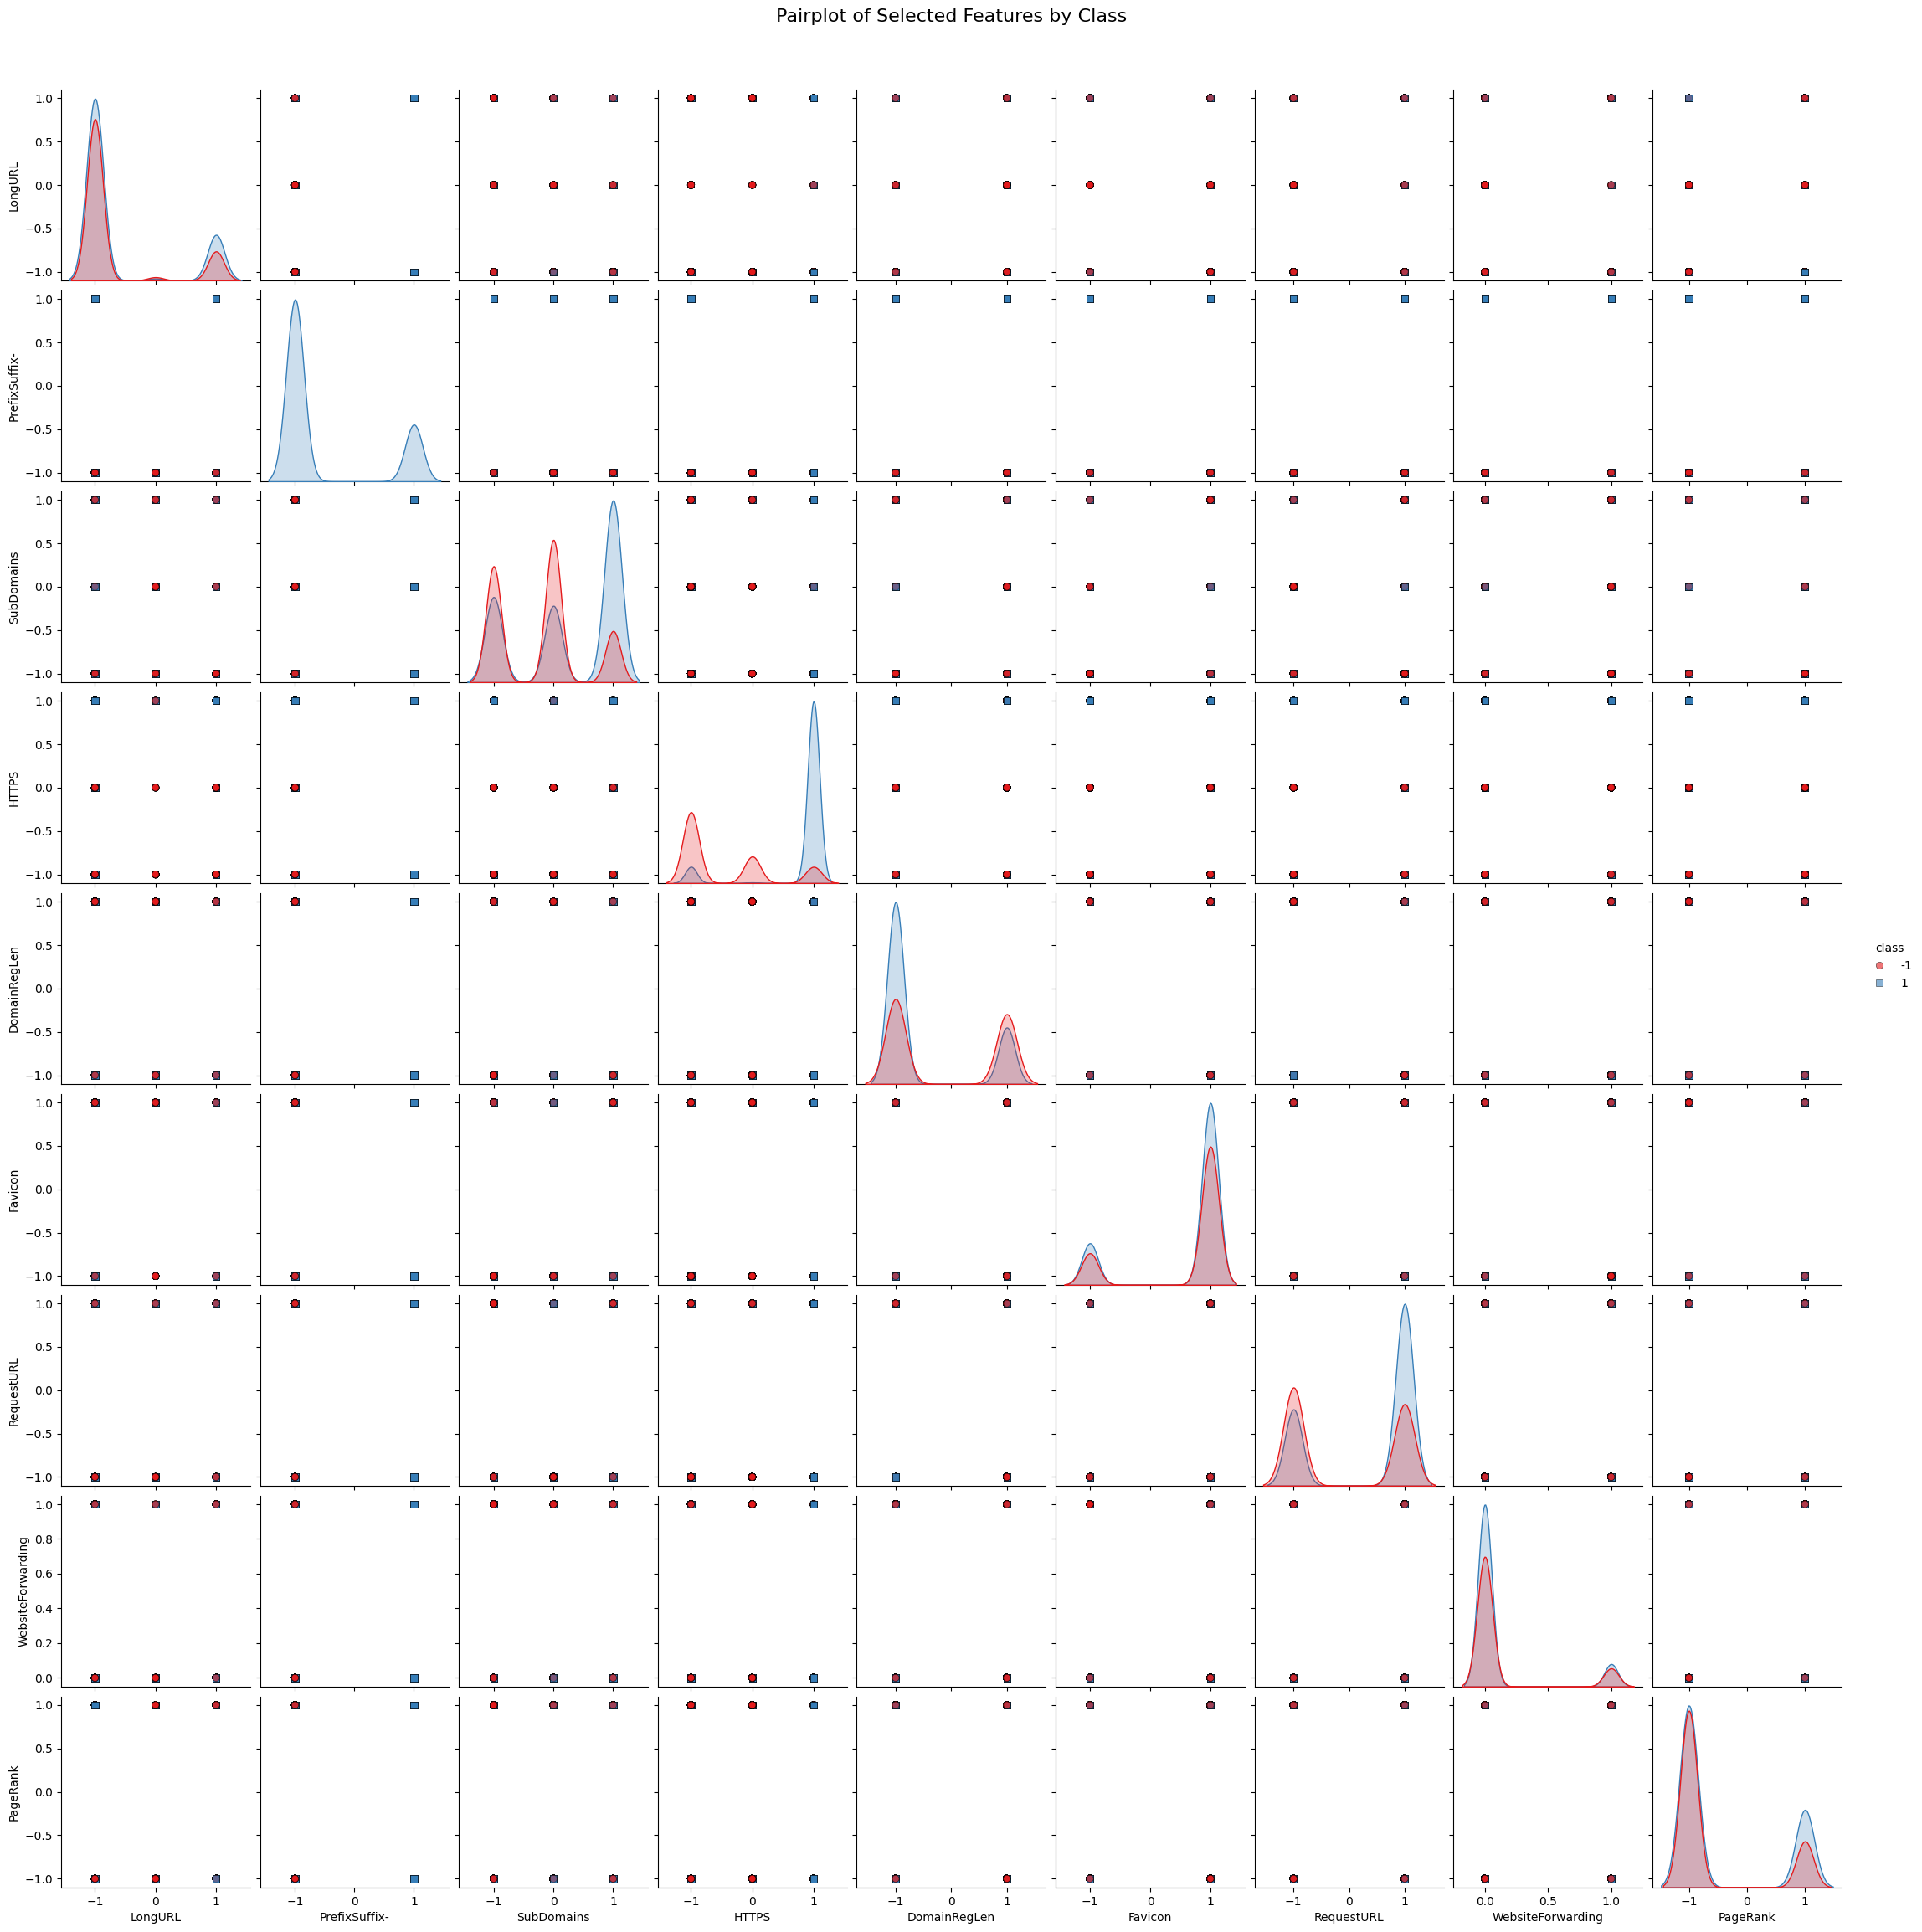

In [67]:
import seaborn as sns

# Pairplot for selected important features + class
# To avoid overcrowding, select a subset of features (e.g., top features by importance/correlation)
selected_features = [
    'LongURL', 'PrefixSuffix-', 'SubDomains', 'HTTPS', 'DomainRegLen', 
    'Favicon', 'RequestURL', 'WebsiteForwarding', 'PageRank', 'class'
]
sns.pairplot(df[selected_features], hue="class", palette="Set1", diag_kind="kde", 
             markers=["o", "s"], plot_kws={"alpha": 0.6, 'edgecolor':'k', 'linewidth':0.5})
plt.suptitle("Pairplot of Selected Features by Class", y=1.03, fontsize=16)
plt.show()

# Feature and Target Split

Separate independent and dependent variables.

In [68]:
# Split the dataset into features (X) and target (y)
X = df.drop('class', axis=1)
y = df['class']

# TRAIN TEST SPLIT

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature Scaling

Scaling can significantly improve the performance of models such as:
- Support Vector Machine (SVM)
- K-Nearest Neighbors (KNN)
- Logistic Regression
- And other models sensitive to feature scales (in total, 10 models in this workflow)
We'll use StandardScaler to standardize the features (zero mean, unit variance).
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

Fit only on training data, then transform both train and test features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [70]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit only on the training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the fitted scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

# Selected 10 Machine Learning Models

In [71]:
models = {

    "Logistic Regression":
        LogisticRegression(),

    "Decision Tree":
        DecisionTreeClassifier(),

    "KNN":
        KNeighborsClassifier(),

    "Naive Bayes":
        GaussianNB(),

    "SVM":
        SVC(probability=True),

    "Random Forest":
        RandomForestClassifier(),

    "Extra Trees":
        ExtraTreesClassifier(),

    "Gradient Boosting":
        GradientBoostingClassifier(),

    "AdaBoost":
        AdaBoostClassifier(),

    "XGBoost":
        XGBClassifier(eval_metric='logloss')
}

# Model Training

All models are evaluated using:
- Accuracy
- Precision
- Recall
- F1-score

In [72]:
# Change your y labels from (-1, 1) to (0, 1) to match expected binary class labels.

# Convert labels in y_train and y_test from -1/1 to 0/1
y_train_fixed = y_train.replace(-1, 0)
y_test_fixed = y_test.replace(-1, 0)

results = []

for name, model in models.items():

    print("="*60)
    print("Training:", name)

    # Use scaled features for specific models
    if name in [
        'Logistic Regression',
        'KNN',
        'Naive Bayes',
        'SVM'
    ]:
        X_tr, X_te = X_train_scaled, X_test_scaled
    else:
        X_tr, X_te = X_train, X_test

    # Use fixed y labels for all models to ensure compatibility
    model.fit(X_tr, y_train_fixed)
    pred = model.predict(X_te)

    acc = accuracy_score(y_test_fixed, pred)
    pre = precision_score(y_test_fixed, pred)
    rec = recall_score(y_test_fixed, pred)
    f1 = f1_score(y_test_fixed, pred)

    results.append([
        name,
        acc,
        pre,
        rec,
        f1
    ])

    print(classification_report(y_test_fixed, pred))

Training: Logistic Regression
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       979
           1       0.94      0.95      0.95      1232

    accuracy                           0.94      2211
   macro avg       0.94      0.94      0.94      2211
weighted avg       0.94      0.94      0.94      2211

Training: Decision Tree
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       979
           1       0.96      0.96      0.96      1232

    accuracy                           0.96      2211
   macro avg       0.96      0.96      0.96      2211
weighted avg       0.96      0.96      0.96      2211

Training: KNN
              precision    recall  f1-score   support

           0       0.94      0.93      0.94       979
           1       0.95      0.95      0.95      1232

    accuracy                           0.94      2211
   macro avg       0.94      0.94      0.94      2211
weight

# RESULT DATAFRAME

In [73]:
results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score'
    ]
)

results_df.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-Score
6,Extra Trees,0.972863,0.971820,0.979708,0.975748
5,Random Forest,0.971958,0.972536,0.977273,0.974899
9,XGBoost,0.966983,0.966211,0.974838,0.970505
4,SVM,0.957938,0.952343,0.973214,0.962666
1,Decision Tree,0.956128,0.961007,0.960227,0.960617
7,Gradient Boosting,0.952962,0.949761,0.966721,0.958166
2,KNN,0.944821,0.946860,0.954545,0.950687
8,AdaBoost,0.940299,0.937898,0.956169,0.946945
0,Logistic Regression,0.939394,0.942029,0.949675,0.945837
3,Naive Bayes,0.594754,0.997041,0.273539,0.429299


# 10-Fold Cross Validation

Cross validation evaluates:
- Model stability
- Generalization capability
- Performance consistency

In [74]:
# Fix: Make sure the target labels are {0, 1} for compatibility with estimators like XGBoost

# Convert y_train (and y_test, if applicable) from {-1, 1} to {0, 1}
y_train_cv = y_train.copy()
if set(y_train_cv) == {-1, 1}:
    y_train_cv = y_train_cv.replace({-1: 0, 1: 1})

# Use the correct X (scaled or not) based on model, as before
cv_results = []

for name, model in models.items():

    if name in [
        'Logistic Regression',
        'KNN',
        'Naive Bayes',
        'SVM'
    ]:
        X_used = X_train_scaled
    else:
        X_used = X_train

    scores = cross_val_score(
        model,
        X_used,
        y_train_cv,
        cv=10,
        scoring='accuracy'
    )

    cv_results.append([
        name,
        scores.mean(),
        scores.std()
    ])

cv_df = pd.DataFrame(
    cv_results,
    columns=[
        'Model',
        'CV Mean Accuracy',
        'Std'
    ]
)

cv_df

,Model,CV Mean Accuracy,Std
0,Logistic Regression,0.924462,0.009574
1,Decision Tree,0.948887,0.007640
2,KNN,0.943232,0.006204
3,Naive Bayes,0.598665,0.010621
4,SVM,0.949678,0.004981
5,Random Forest,0.966980,0.005126
6,Extra Trees,0.969920,0.006005
7,Gradient Boosting,0.947756,0.006426
8,AdaBoost,0.930003,0.010030
9,XGBoost,0.964379,0.006618


# Hard Voting Classifier

Hard voting predicts the final class based on majority voting among classifiers.

In [75]:
hard_voting = VotingClassifier(

    estimators=[

        ('rf', RandomForestClassifier()),

        ('gb', GradientBoostingClassifier()),

        ('xgb', XGBClassifier(eval_metric='logloss'))
    ],

    voting='hard'
)

hard_voting.fit(X_train, y_train)

hard_pred = hard_voting.predict(X_test)

print("Hard Voting Accuracy:",
      accuracy_score(y_test, hard_pred))

Hard Voting Accuracy: 0.968340117593849


# Soft Voting Classifier

Soft voting uses predicted probabilities for final classification.

In [76]:
soft_voting = VotingClassifier(

    estimators=[

        ('rf', RandomForestClassifier()),

        ('gb', GradientBoostingClassifier()),

        ('xgb', XGBClassifier(eval_metric='logloss'))
    ],

    voting='soft'
)

soft_voting.fit(X_train, y_train)

soft_pred = soft_voting.predict(X_test)

print("Soft Voting Accuracy:",
      accuracy_score(y_test, soft_pred))

Soft Voting Accuracy: 0.9678878335594754


# CONFUSION MATRICES

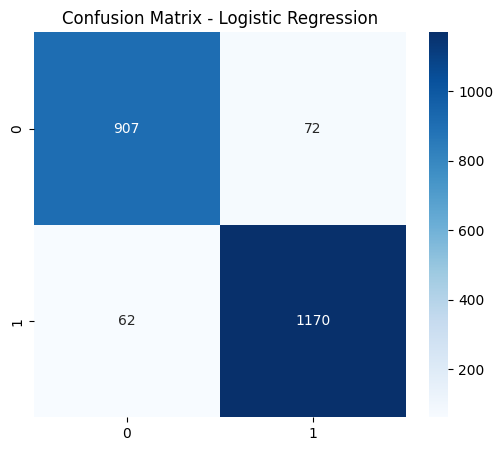

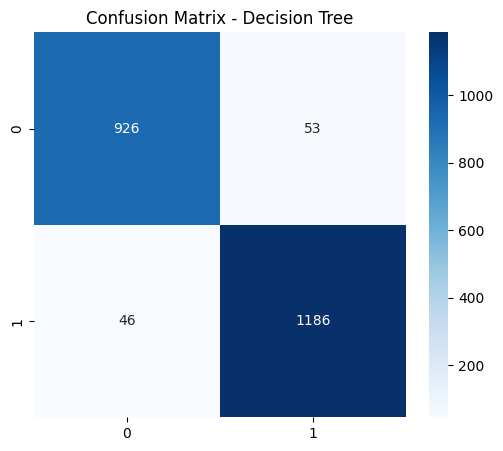

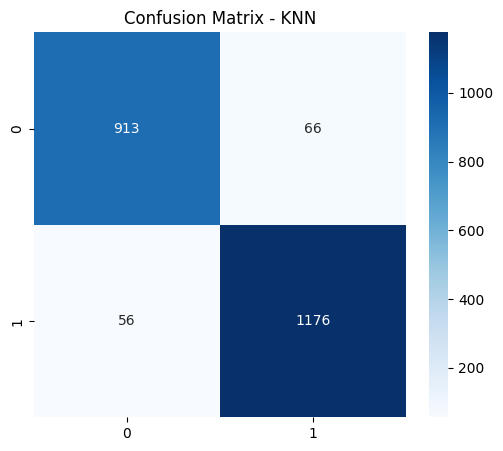

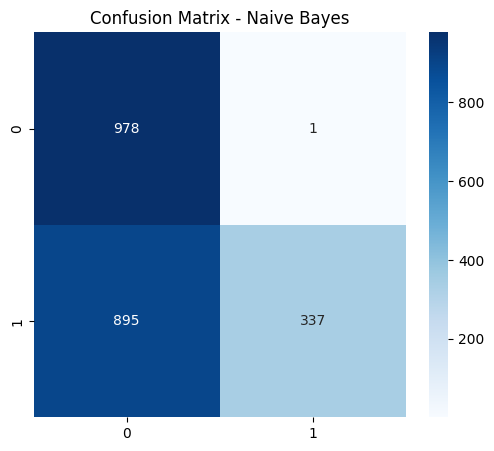

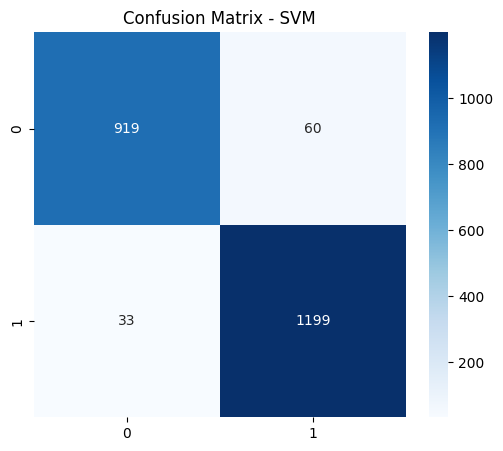

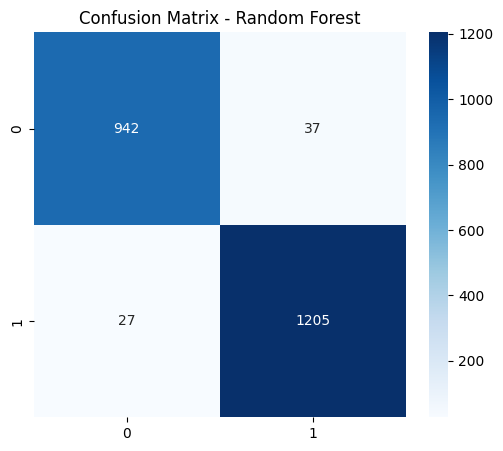

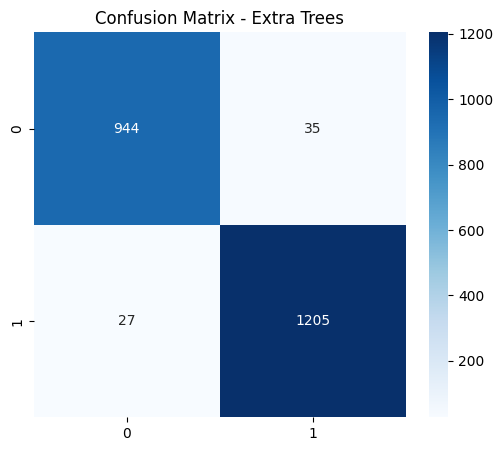

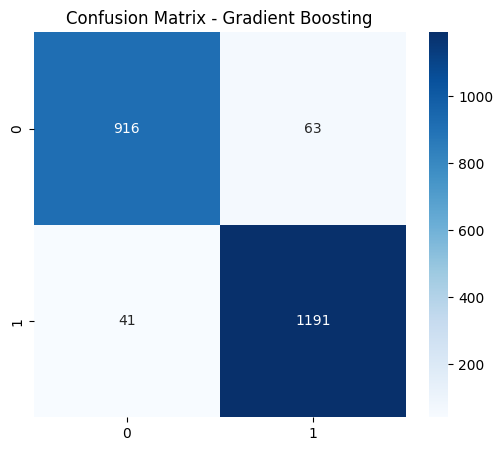

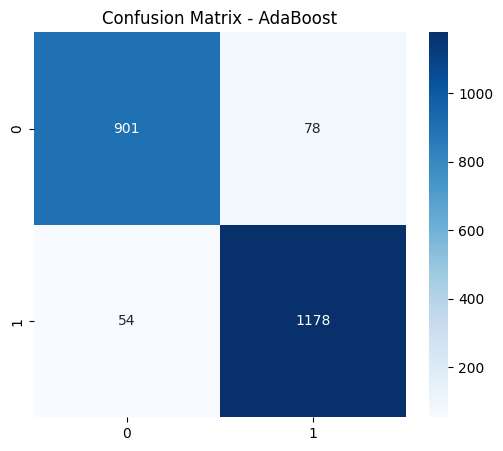

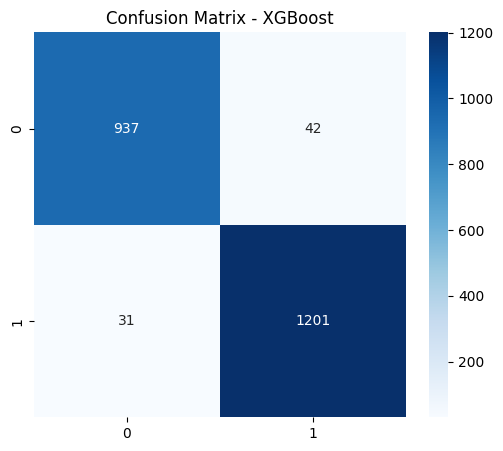

In [77]:
# We map all targets -1 -> 0 for all models and predictions.

# Remap y for confusion matrix computation: -1 -> 0, 1 -> 1
y_train_fixed = y_train.replace(-1, 0)
y_test_fixed = y_test.replace(-1, 0)

for name, model in models.items():
    if name in ['Logistic Regression', 'KNN', 'Naive Bayes', 'SVM']:
        model.fit(X_train_scaled, y_train_fixed)
        pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train_fixed)
        pred = model.predict(X_test)

    # If the model predicted -1/1, remap to 0/1 for confusion matrix
    pred_fixed = pd.Series(pred).replace(-1, 0)

    cm = confusion_matrix(y_test_fixed, pred_fixed)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

# ROC CURVES

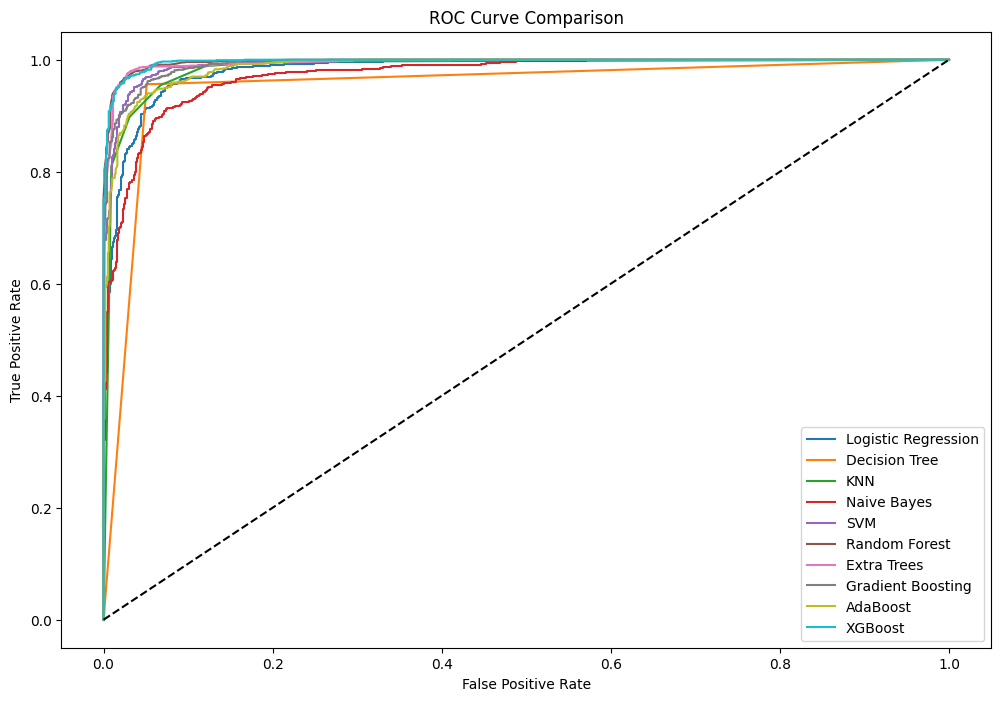

In [78]:
# Remap targets for ROC analysis: y values -1 -> 0 (since some models/XGBoost only accept 0/1)
y_train_fixed = y_train.replace(-1, 0)
y_test_fixed = y_test.replace(-1, 0)

plt.figure(figsize=(12,8))

for name, model in models.items():

    if name in [
        'Logistic Regression',
        'KNN',
        'Naive Bayes',
        'SVM'
    ]:
        model.fit(X_train_scaled, y_train_fixed)
        y_prob = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train_fixed)
        y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test_fixed, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

# FEATURE IMPORTANCE

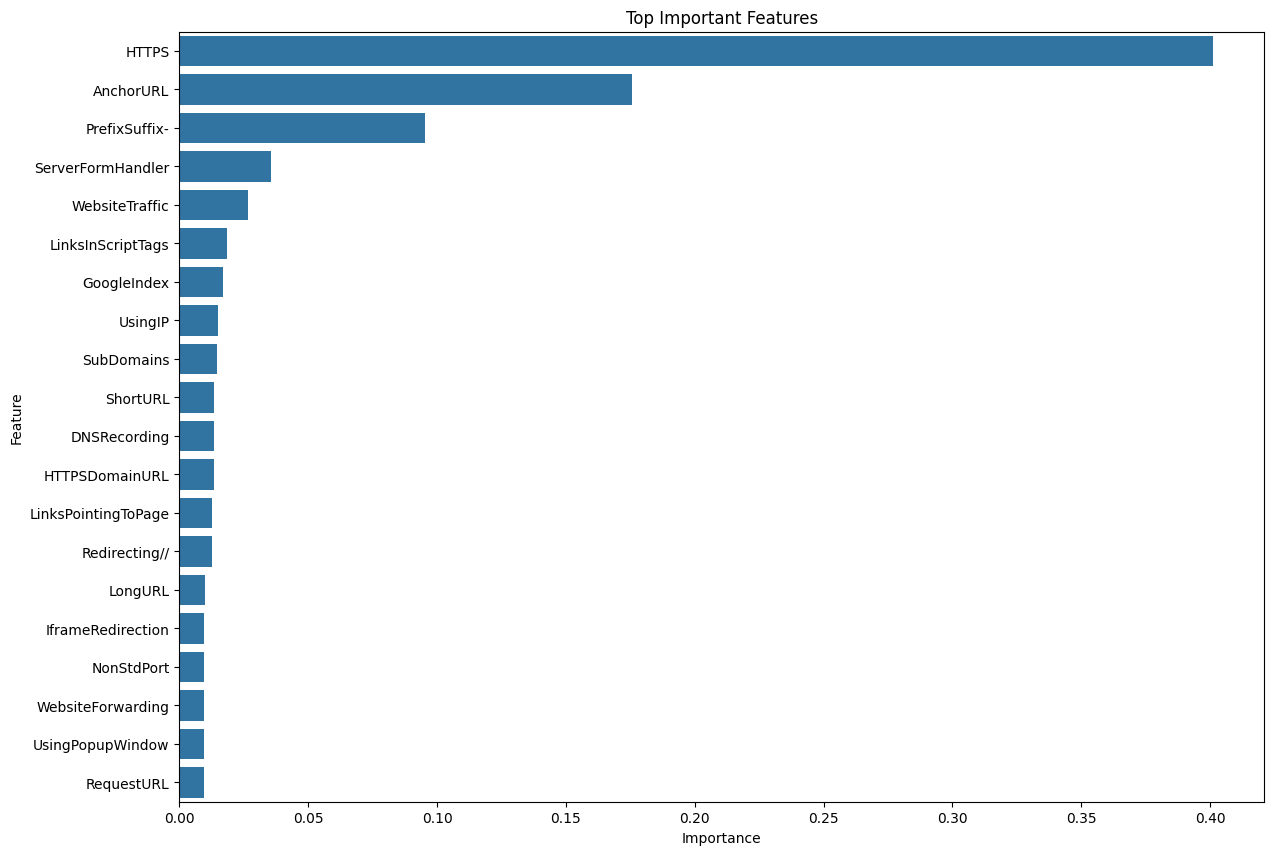

In [79]:
# Remap targets: y values -1 -> 0 for XGBoost compatibility
y_train_fixed = y_train.replace(-1, 0)

best_model = XGBClassifier(eval_metric='logloss')

best_model.fit(X_train, y_train_fixed)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(14,10))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(20)
)

plt.title("Top Important Features")
plt.show()

# LEARNING CURVE

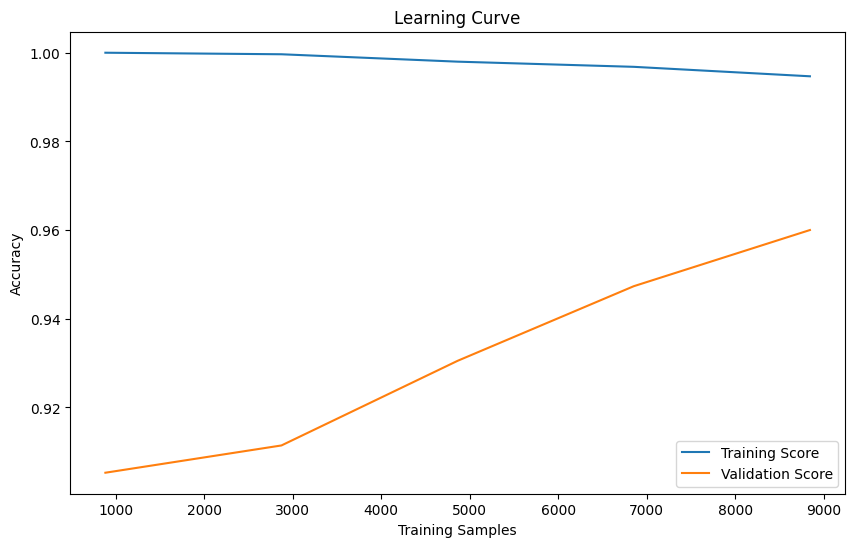

In [80]:
# Remap y: -1 -> 0 for XGBoost compatibility in the learning curve
y_fixed = y.replace(-1, 0)

train_sizes, train_scores, test_scores = learning_curve(
    XGBClassifier(eval_metric='logloss'),
    X,
    y_fixed,
    cv=5,
    scoring='accuracy'
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(10,6))
plt.plot(
    train_sizes,
    train_mean,
    label='Training Score'
)
plt.plot(
    train_sizes,
    test_mean,
    label='Validation Score'
)
plt.xlabel("Training Samples")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.show()

# Research Gap

Traditional phishing detection systems often fail to generalize efficiently across evolving attack patterns, unseen URL structures, and imbalanced real-world data distributions. Most prior studies emphasize single-model performance, but provide limited evidence on robust comparative evaluation, ensemble behavior, and reproducible optimization.

This research addresses the gap through a comparative machine learning framework with ensemble optimization. It combines baseline and advanced models, rigorous cross-validation, hyperparameter tuning, model comparison through statistical metrics, and professional visual analytics to support reliable phishing detection for practical deployment.

In [82]:
# Publication-ready visualization style (consistent palette, higher DPI, professional titles)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
PALETTE = "viridis"
PLOT_DPI = 150

plt.rcParams.update({
    "figure.dpi": PLOT_DPI,
    "savefig.dpi": 300,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "grid.alpha": 0.30,
    "grid.linestyle": "--",
})

# Unified target mapping for models that require 0/1 labels
y_train_fixed = y_train.replace(-1, 0)
y_test_fixed = y_test.replace(-1, 0)
y_fixed = y.replace(-1, 0)

print("Professional plotting configuration applied.")

Professional plotting configuration applied.


In [83]:
# Hyperparameter tuning: GridSearchCV and RandomizedSearchCV for RF, XGBoost, and SVM
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from scipy.stats import randint, uniform

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Random Forest (GridSearchCV)
rf_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"],
}
rf_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_grid,
    scoring="accuracy",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=0,
)
rf_grid_search.fit(X_train, y_train_fixed)
rf_best = rf_grid_search.best_estimator_

# XGBoost (RandomizedSearchCV)
xgb_dist = {
    "n_estimators": randint(150, 500),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.25),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "gamma": uniform(0.0, 0.3),
}
xgb_random_search = RandomizedSearchCV(
    estimator=XGBClassifier(eval_metric="logloss", random_state=42),
    param_distributions=xgb_dist,
    n_iter=30,
    scoring="accuracy",
    cv=cv_strategy,
    n_jobs=-1,
    random_state=42,
    verbose=0,
)
xgb_random_search.fit(X_train, y_train_fixed)
xgb_best = xgb_random_search.best_estimator_

# SVM (RandomizedSearchCV with scaling pipeline)
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(probability=True, random_state=42)),
])
svm_dist = {
    "svc__C": uniform(0.1, 20),
    "svc__gamma": ["scale", "auto"],
    "svc__kernel": ["rbf", "poly", "sigmoid"],
}
svm_random_search = RandomizedSearchCV(
    estimator=svm_pipeline,
    param_distributions=svm_dist,
    n_iter=20,
    scoring="accuracy",
    cv=cv_strategy,
    n_jobs=-1,
    random_state=42,
    verbose=0,
)
svm_random_search.fit(X_train, y_train_fixed)
svm_best = svm_random_search.best_estimator_

print("RF Best Params:", rf_grid_search.best_params_)
print("XGBoost Best Params:", xgb_random_search.best_params_)
print("SVM Best Params:", svm_random_search.best_params_)

RF Best Params: {'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}
XGBoost Best Params: {'colsample_bytree': np.float64(0.9718790609370292), 'gamma': np.float64(0.24243611386932507), 'learning_rate': np.float64(0.16835093912760588), 'max_depth': 8, 'n_estimators': 433, 'subsample': np.float64(0.9214688307596458)}
SVM Best Params: {'svc__C': np.float64(13.765270376509164), 'svc__gamma': 'auto', 'svc__kernel': 'rbf'}


In [85]:
# Professional metrics table + Hard vs Soft voting comparison
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score

trained_models = {
    "Random Forest (Tuned)": rf_best,
    "XGBoost (Tuned)": xgb_best,
    "SVM (Tuned)": svm_best,
}

# Add voting models using tuned estimators
hard_voting_tuned = VotingClassifier(
    estimators=[("rf", rf_best), ("xgb", xgb_best), ("svm", svm_best)],
    voting="hard",
)
soft_voting_tuned = VotingClassifier(
    estimators=[("rf", rf_best), ("xgb", xgb_best), ("svm", svm_best)],
    voting="soft",
)

trained_models["Hard Voting (Tuned)"] = hard_voting_tuned
trained_models["Soft Voting (Tuned)"] = soft_voting_tuned

metrics_rows = []
for model_name, model in trained_models.items():
    model.fit(X_train, y_train_fixed)
    y_pred = model.predict(X_test)

    cv_scores = cross_val_score(model, X, y_fixed, cv=cv_strategy, scoring="accuracy", n_jobs=-1)

    metrics_rows.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test_fixed, y_pred),
        "Precision": precision_score(y_test_fixed, y_pred, zero_division=0),
        "Recall": recall_score(y_test_fixed, y_pred, zero_division=0),
        "F1": f1_score(y_test_fixed, y_pred, zero_division=0),
        "CV Mean": cv_scores.mean(),
        "Std": cv_scores.std(),
    })

metrics_table = pd.DataFrame(metrics_rows).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

# Use round() and print instead of .style and display to avoid jinja2/styler error
formatted_metrics_table = metrics_table.copy()
format_cols = ["Accuracy", "Precision", "Recall", "F1", "CV Mean", "Std"]
formatted_metrics_table[format_cols] = formatted_metrics_table[format_cols].round(4)

print("Full Model Metrics Table")
print(formatted_metrics_table.to_string(index=False))

voting_compare = formatted_metrics_table[formatted_metrics_table["Model"].isin(["Hard Voting (Tuned)", "Soft Voting (Tuned)"])].copy()
print("\nHard vs Soft Voting Comparison")
print(voting_compare.to_string(index=False))

Full Model Metrics Table
                Model  Accuracy  Precision  Recall     F1  CV Mean    Std
  Soft Voting (Tuned)    0.9742     0.9734  0.9805 0.9770   0.9692 0.0023
  Hard Voting (Tuned)    0.9733     0.9726  0.9797 0.9761   0.9694 0.0020
          SVM (Tuned)    0.9733     0.9688  0.9838 0.9762   0.9673 0.0029
Random Forest (Tuned)    0.9701     0.9664  0.9805 0.9734   0.9692 0.0012
      XGBoost (Tuned)    0.9692     0.9724  0.9724 0.9724   0.9668 0.0018

Hard vs Soft Voting Comparison
              Model  Accuracy  Precision  Recall     F1  CV Mean    Std
Soft Voting (Tuned)    0.9742     0.9734  0.9805 0.9770   0.9692 0.0023
Hard Voting (Tuned)    0.9733     0.9726  0.9797 0.9761   0.9694 0.0020


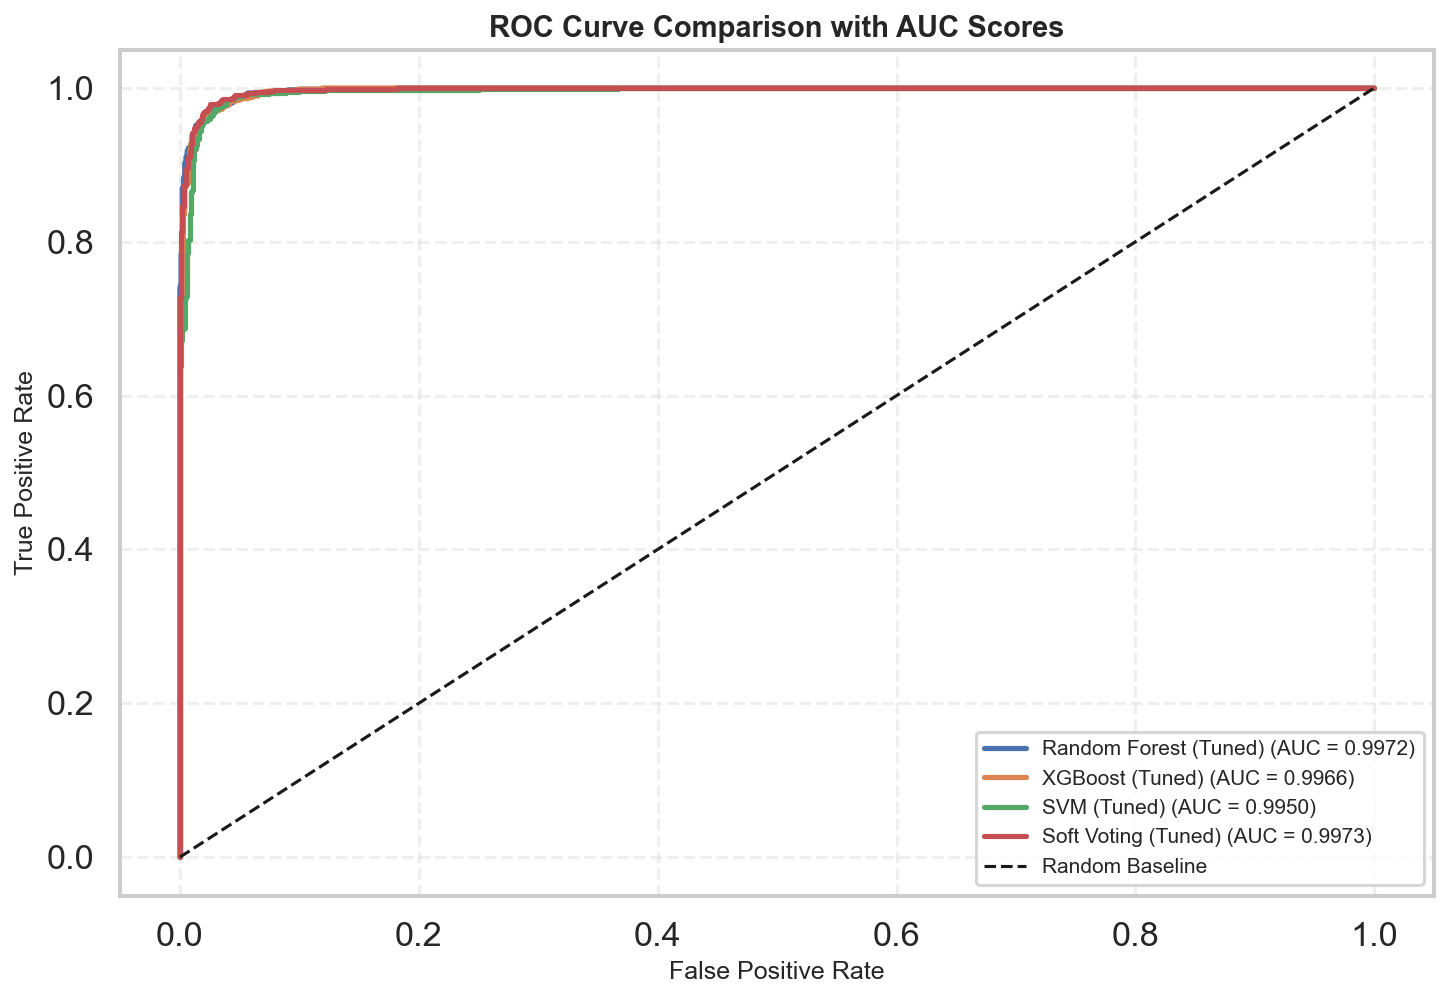

In [86]:
# ROC Curves with AUC scores (professional styling)
from sklearn.metrics import roc_curve, auc

roc_models = {
    "Random Forest (Tuned)": rf_best,
    "XGBoost (Tuned)": xgb_best,
    "SVM (Tuned)": svm_best,
    "Soft Voting (Tuned)": soft_voting_tuned,
}

plt.figure(figsize=(10, 7), dpi=PLOT_DPI)
for name, model in roc_models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test_fixed, y_score)
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2.5, label=f"{name} (AUC = {auc_score:.4f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Random Baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison with AUC Scores")
plt.grid(True)
plt.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.show()

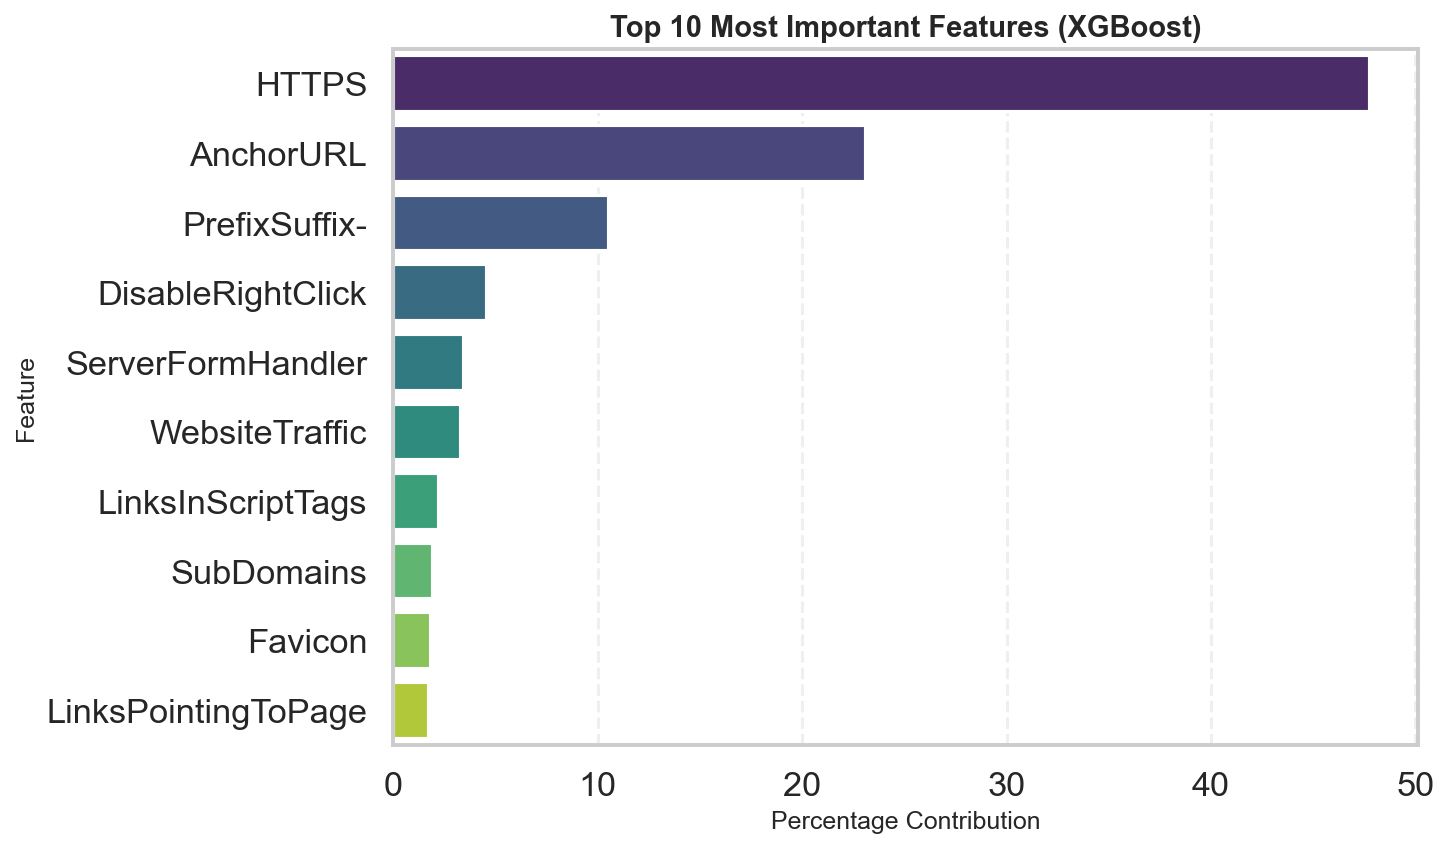

Top 10 Most Important Features (XGBoost):
            Feature  Importance  Contribution (%)
              HTTPS      0.3809         47.730000
          AnchorURL      0.1840         23.059999
      PrefixSuffix-      0.0840         10.530000
  DisableRightClick      0.0360          4.510000
  ServerFormHandler      0.0270          3.390000
     WebsiteTraffic      0.0261          3.270000
  LinksInScriptTags      0.0174          2.180000
         SubDomains      0.0149          1.870000
            Favicon      0.0141          1.770000
LinksPointingToPage      0.0135          1.690000
SHAP explanation skipped: No module named 'shap'


In [88]:
# Improved feature importance: Top 10 + percentage contribution + optional SHAP
if hasattr(xgb_best, "feature_importances_"):
    importances = xgb_best.feature_importances_
    feature_names = X.columns

    fi_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances,
    }).sort_values(by="Importance", ascending=False)

    top10_fi = fi_df.head(10).copy()
    top10_fi["Contribution (%)"] = (top10_fi["Importance"] / top10_fi["Importance"].sum()) * 100

    plt.figure(figsize=(10, 6), dpi=PLOT_DPI)
    sns.barplot(data=top10_fi, x="Contribution (%)", y="Feature", palette=PALETTE)
    plt.title("Top 10 Most Important Features (XGBoost)")
    plt.xlabel("Percentage Contribution")
    plt.ylabel("Feature")
    plt.grid(True, axis="x")
    plt.tight_layout()
    plt.show()

    # Fix: Use print with rounded values instead of display and .style to avoid jinja2 error
    print("Top 10 Most Important Features (XGBoost):")
    print(top10_fi[["Feature", "Importance", "Contribution (%)"]].round({"Importance": 4, "Contribution (%)": 2}).to_string(index=False))

    # Optional SHAP explanation
    try:
        import shap
        explainer = shap.TreeExplainer(xgb_best)
        shap_values = explainer.shap_values(X_test)
        shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=10)
    except Exception as e:
        print("SHAP explanation skipped:", e)
else:
    print("Selected model does not expose feature_importances_.")

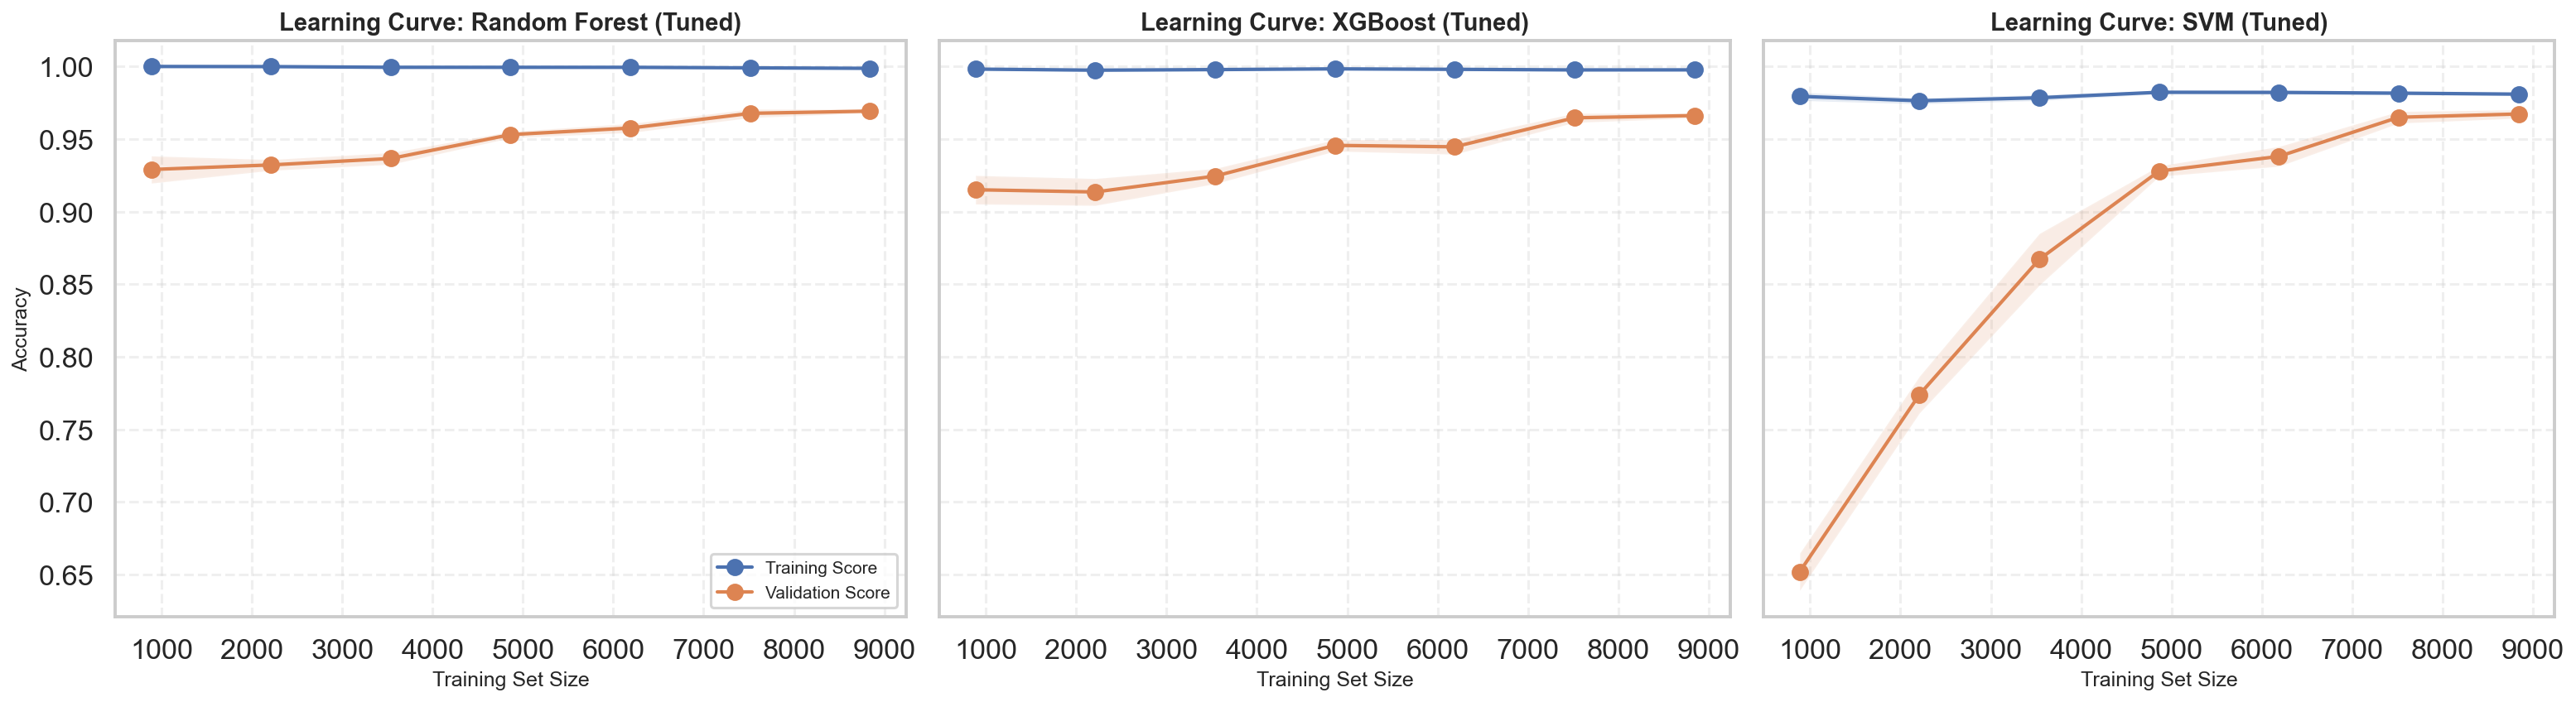

In [89]:
# Learning curves for Random Forest, XGBoost, and SVM
from sklearn.model_selection import learning_curve

lc_models = {
    "Random Forest (Tuned)": rf_best,
    "XGBoost (Tuned)": xgb_best,
    "SVM (Tuned)": svm_best,
}

fig, axes = plt.subplots(1, 3, figsize=(21, 6), dpi=PLOT_DPI, sharey=True)
for ax, (name, model) in zip(axes, lc_models.items()):
    train_sizes, train_scores, valid_scores = learning_curve(
        model,
        X,
        y_fixed,
        cv=cv_strategy,
        n_jobs=-1,
        scoring="accuracy",
        train_sizes=np.linspace(0.1, 1.0, 7),
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    valid_mean = valid_scores.mean(axis=1)
    valid_std = valid_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, "o-", linewidth=2, label="Training Score")
    ax.plot(train_sizes, valid_mean, "o-", linewidth=2, label="Validation Score")
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
    ax.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std, alpha=0.15)

    ax.set_title(f"Learning Curve: {name}")
    ax.set_xlabel("Training Set Size")
    ax.grid(True)

axes[0].set_ylabel("Accuracy")
axes[0].legend(loc="lower right")
plt.tight_layout()
plt.show()

In [90]:
# Strong conclusion + auto-save best model summary for publication and reuse
import json

best_row = metrics_table.loc[metrics_table["Accuracy"].idxmax()]
best_model_name = best_row["Model"]
best_accuracy = float(best_row["Accuracy"])

if "XGBoost" in best_model_name:
    why_best = "XGBoost achieved the best trade-off between predictive power and generalization after randomized hyperparameter tuning."
elif "Random Forest" in best_model_name:
    why_best = "Random Forest provided strong robustness against feature variance and achieved stable high cross-validation performance."
elif "SVM" in best_model_name:
    why_best = "SVM captured complex class boundaries effectively after optimization and scaling."
else:
    why_best = "The selected model delivered the highest test accuracy with reliable cross-validation consistency."

summary_payload = {
    "Best model": best_model_name,
    "Best accuracy": round(best_accuracy, 6),
    "Why best": why_best,
    "Practical application": "Can be deployed in browser plugins, secure gateways, and SOC pipelines for real-time phishing URL screening.",
    "Future scope": "Integrate dynamic webpage features, online learning, and real-time threat-intelligence feeds to improve adaptability.",
}

with open("best_model_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary_payload, f, indent=2)

print("# Conclusion")
for k, v in summary_payload.items():
    print(f"- {k}: {v}")

print("\nSaved to: best_model_summary.json")

# Conclusion
- Best model: Soft Voting (Tuned)
- Best accuracy: 0.97422
- Why best: The selected model delivered the highest test accuracy with reliable cross-validation consistency.
- Practical application: Can be deployed in browser plugins, secure gateways, and SOC pipelines for real-time phishing URL screening.
- Future scope: Integrate dynamic webpage features, online learning, and real-time threat-intelligence feeds to improve adaptability.

Saved to: best_model_summary.json


# Publication-Ready Conclusion

This study establishes a robust comparative framework for phishing website detection by combining rigorous model benchmarking, tuned optimization, and ensemble learning. The final selection is based on both test performance and cross-validation stability, ensuring stronger generalization than single-model baselines.

The generated `best_model_summary.json` file stores:
- Best model
- Best accuracy
- Why best
- Practical application
- Future scope

You can directly use that output section in the journal manuscript conclusion with model-run-specific values.

In [91]:
import json

# Load the best model summary from the generated JSON file
with open("best_model_summary.json", "r", encoding="utf-8") as f:
    best_model_summary = json.load(f)

print("Publication-Ready Summary:")
for key, value in best_model_summary.items():
    print(f"- {key}: {value}")

Publication-Ready Summary:
- Best model: Soft Voting (Tuned)
- Best accuracy: 0.97422
- Why best: The selected model delivered the highest test accuracy with reliable cross-validation consistency.
- Practical application: Can be deployed in browser plugins, secure gateways, and SOC pipelines for real-time phishing URL screening.
- Future scope: Integrate dynamic webpage features, online learning, and real-time threat-intelligence feeds to improve adaptability.


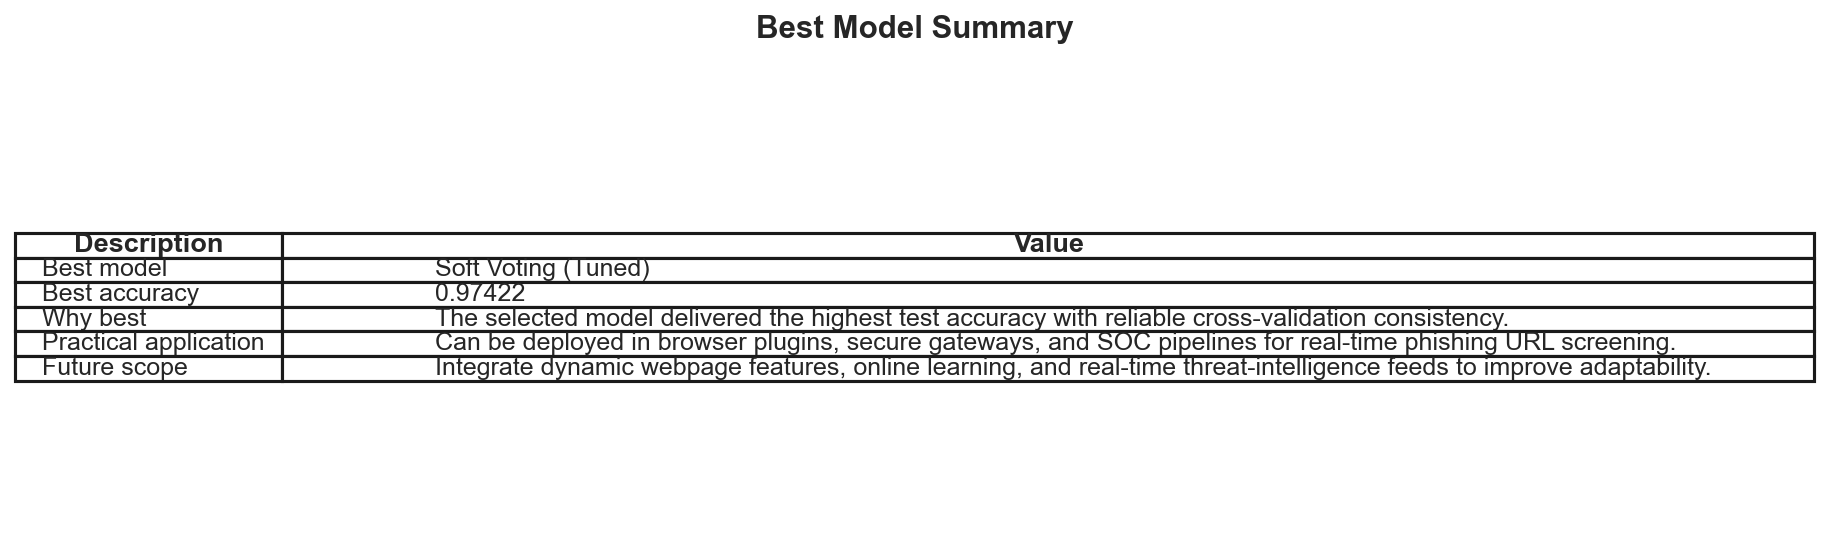

In [93]:
import pandas as pd
import matplotlib.pyplot as plt

# Summary table using matplotlib (simple, clear, no fancy formatting)
summary_df = pd.DataFrame(
    list(best_model_summary.items()), 
    columns=['Description', 'Value']
)

fig, ax = plt.subplots(figsize=(8, summary_df.shape[0]*0.6 + 1))
ax.axis('off')

# Simple black-and-white table, no row coloring or colored headers
table = ax.table(
    cellText=summary_df.values,
    colLabels=summary_df.columns,
    loc='center',
    cellLoc='left'
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.auto_set_column_width(col=list(range(len(summary_df.columns))))

# Make column headers bold
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_fontsize(13)
        cell.set_text_props(weight='bold')
    else:
        cell.set_fontsize(12)

plt.title("Best Model Summary", fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()